# Canadian Politics and Economic Prosperity (1980–2025)

This notebook studies whether the **governing political party in Canada** is associated with differences in economic prosperity between **1980 and 2025**.

## What this notebook is

A very simple question:

> **Does Canada's economy look better or worse depending on which federal party is in power?**

To explore that question, we use economic outcomes:

- **Unemployment rate**
- **Inflation rate**
- **GDP growth**
- **Interest rate**
- **War**(added)
- **US Administration**(added)

## What is included

This notebook includes:

- data cleaning and annual dataset building
- graphs and visualizations
- t-tests and ANOVA
- effect sizes
- regressions
- interaction models
- lagged ideology models
- correlation matrix
- normality checks
- outlier checks
- bootstrap and permutation tests
- sensitivity analysis
- DiD-style event models
- Chow structural break tests
- chi-square tests
- Appendix (Causal Inference)



This notebook looks for **statistical association**, not perfect proof of causation, so add simple causal inference block as a appendix



# 1. Objective

The purpose of this study is to evaluate whether the **governing federal political party in Canada** is associated with different economic outcomes from **1980 to 2025**.

In simple terms:

> Does Canada's economy look meaningfully different depending on which federal party governs?

Evaluate this question using four economic indicators:


> Add blockquote


1. unemployment rate  
2. inflation rate  
3. GDP growth  
4. interest rate
5. War (added)
6. US Administration (added)

# 2. Hypothesis

## Null Hypothesis ($H_0$)
The governing political party has **no effect** on the economic outcomes.

## Alternative Hypothesis ($H_1$)
The governing political party is associated with **different economic outcomes**.

This idea using multiple statistical methods, not just one.

# 3. Statistical Plan

This notebook applies several families of methods.

## A. Group comparison tests
- Welch t-test
- ANOVA
- Mann–Whitney U test
- effect size estimation
- bootstrap confidence intervals
- permutation tests

## B. Regression analysis
- baseline regressions
- regressions with confounders
- interaction models
- time-trend interactions
- lagged ideology models

## C. Diagnostics and robustness
- normality tests
- outlier checks
- sensitivity analysis
- structural break tests
- chi-square test of independence

## D. Visualization
- line plots
- box plots
- histograms
- density-like histograms
- scatter plots
- correlation heatmap
- party-period plots

## E. Appendix : Causal Inference

# 4. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from scipy import stats
from scipy.stats import shapiro, jarque_bera, mannwhitneyu, chi2_contingency
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.stattools import jarque_bera as sm_jarque_bera
from statsmodels.stats.outliers_influence import OLSInfluence

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
np.random.seed(42)

## Project setup

In [2]:
# Project definitions and configuration
GOVERNMENT_CSV = "wiki-government_party.csv"
GDP_GROWTH_CSV = "worldbank-API_NY.GDP.MKTP.KD.ZG_DS2_en_csv_v2_107.csv"
UNEMPLOYMENT_CSV = "statscan-1410028701_database.csv"
INFLATION_CSV = "statscan-1810000401_database.csv"
INTEREST_CSV = "bankofcanada-V39079_overnight_rate.csv"

# Data value constants
LIBERAL_CODE = "L"
LIBERAL_NAME = "Liberal"
CONSERVATIVE_CODE = "C"
CONSERVATIVE_NAME = "Conservative"

# Figure colours and constants
LIBERAL_COLOR = "#d71b1f"
CONSERVATIVE_COLOR = "#1d4881"
NEUTRAL_COLOR = "#555"
PARTY_COLOR_MAP = { LIBERAL_CODE: LIBERAL_COLOR, CONSERVATIVE_CODE: CONSERVATIVE_COLOR }
PARTY_LEGEND = [
    Patch(facecolor=(LIBERAL_COLOR, 0.40), label=LIBERAL_NAME),
    Patch(facecolor=(CONSERVATIVE_COLOR, 0.40), label=CONSERVATIVE_NAME)
]
YEAR_X_TICKS = list(range(1980, 2026, 4))

# 5. Load Data

In [3]:
# Get runtime data directory
import os
from pathlib import Path

def get_data_dir():
    """
    Resolve the data directory according to the runtime environment: local or Google Colab.
    """
    try:
        # If Google Colab detected, then point to public data repository
        import google.colab
        return "https://raw.githubusercontent.com/xactivecom/Waterloo-SCS3584-Project/master/data"
    except ImportError:
        # Running locally
        return Path(__file__).parent if "__file__" in dir() else Path.cwd() / "data"

DATA_DIR = get_data_dir()
print(f"Data directory: {DATA_DIR}")

Data directory: /Users/stuartthompson/Courses/Waterloo/SCS3584-Project/group2/data


In [4]:
# Load data files
party = pd.read_csv(f"{DATA_DIR}/{GOVERNMENT_CSV}")
gdp = pd.read_csv(f"{DATA_DIR}/{GDP_GROWTH_CSV}")
unemp = pd.read_csv(f"{DATA_DIR}/{UNEMPLOYMENT_CSV}")
cpi = pd.read_csv(f"{DATA_DIR}/{INFLATION_CSV}")
rate = pd.read_csv(f"{DATA_DIR}/{INTEREST_CSV}")

# 6. Inspect Raw Data

In [5]:
print("Unemployment")
display(unemp.head())
print(unemp.columns.tolist())

print("\nCPI")
display(cpi.head())
print(cpi.columns.tolist())

print("\nParty")
display(party.head())
print(party.columns.tolist())

print("\nGDP")
display(gdp.head())
print(gdp.columns.tolist())

print("\nInterest rate")
display(rate.head())
print(rate.columns.tolist())

Unemployment


,REF_DATE,GEO,DGUID,Labour force characteristics,Gender,Age group,Statistics,Data type,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,1980-01,Canada,2021A000011124,Unemployment rate,Total - Gender,15 years and over,Estimate,Seasonally adjusted,Percent,239,units,0,v2062815,1.7.1.1.1.1,7.5,NaN,NaN,NaN,1
1,1980-02,Canada,2021A000011124,Unemployment rate,Total - Gender,15 years and over,Estimate,Seasonally adjusted,Percent,239,units,0,v2062815,1.7.1.1.1.1,7.6,NaN,NaN,NaN,1
2,1980-03,Canada,2021A000011124,Unemployment rate,Total - Gender,15 years and over,Estimate,Seasonally adjusted,Percent,239,units,0,v2062815,1.7.1.1.1.1,7.6,NaN,NaN,NaN,1
3,1980-04,Canada,2021A000011124,Unemployment rate,Total - Gender,15 years and over,Estimate,Seasonally adjusted,Percent,239,units,0,v2062815,1.7.1.1.1.1,7.7,NaN,NaN,NaN,1
4,1980-05,Canada,2021A000011124,Unemployment rate,Total - Gender,15 years and over,Estimate,Seasonally adjusted,Percent,239,units,0,v2062815,1.7.1.1.1.1,7.8,NaN,NaN,NaN,1


['REF_DATE', 'GEO', 'DGUID', 'Labour force characteristics', 'Gender', 'Age group', 'Statistics', 'Data type', 'UOM', 'UOM_ID', 'SCALAR_FACTOR', 'SCALAR_ID', 'VECTOR', 'COORDINATE', 'VALUE', 'STATUS', 'SYMBOL', 'TERMINATED', 'DECIMALS']

CPI


,REF_DATE,GEO,DGUID,Products and product groups,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,1980-01,Canada,2016A000011124,All-items,2002=100,17,units,0,v41690973,2.2,41.8,NaN,NaN,NaN,1
1,1980-02,Canada,2016A000011124,All-items,2002=100,17,units,0,v41690973,2.2,42.3,NaN,NaN,NaN,1
2,1980-03,Canada,2016A000011124,All-items,2002=100,17,units,0,v41690973,2.2,42.6,NaN,NaN,NaN,1
3,1980-04,Canada,2016A000011124,All-items,2002=100,17,units,0,v41690973,2.2,42.9,NaN,NaN,NaN,1
4,1980-05,Canada,2016A000011124,All-items,2002=100,17,units,0,v41690973,2.2,43.4,NaN,NaN,NaN,1


['REF_DATE', 'GEO', 'DGUID', 'Products and product groups', 'UOM', 'UOM_ID', 'SCALAR_FACTOR', 'SCALAR_ID', 'VECTOR', 'COORDINATE', 'VALUE', 'STATUS', 'SYMBOL', 'TERMINATED', 'DECIMALS']

Party


...

['year', 'party_code', 'party_full', 'prime_minister', 'minority_government', 'conservative_seats', 'liberal_seats', 'ndp_seats', 'other_seats', 'total_seats', 'notes']

GDP


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.078431,18.648649,12.129841,3.961402,7.962872,5.882354,7.307693,8.203901,2.547144,1.185789,7.046875,1.991984,1.238042,7.622921,4.182002,-0.944953,1.110505,7.293728,-0.383138,1.127411,3.089544,1.835755,-11.677741,-2.733457,3.369237,-1.040800,6.431461,1.426099,3.611480,1.234335,3.493430,3.212471,1.225112,-23.897990,14.730616,10.636431,7.706798,6.810777,NaN,NaN
1,Africa Eastern and Southern,AFE,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,NaN,0.418937,7.937038,5.623764,4.649241,5.138168,4.827421,5.338839,4.156334,5.121587,1.112513,5.482264,2.763764,4.621172,5.472386,1.374547,2.349856,1.110279,1.480865,2.927962,5.452185,3.928672,0.308938,0.063606,3.405639,-0.085865,2.271252,3.938554,4.286398,2.666045,0.121363,-0.106034,-2.395284,-0.839118,1.919654,4.354618,5.499111,3.856739,1.775172,2.634184,3.181375,3.503533,3.917113,3.009372,5.634698,6.173659,6.637497,6.700033,4.437529,0.919473,5.307904,4.077477,1.897173,4.356682,3.920390,2.934030,2.130117,2.677524,2.705194,2.030077,-2.817572,4.578772,3.722717,1.931160,2.763839,NaN,NaN
2,Afghanistan,AFG,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-9.431974,28.600001,8.832278,1.414118,11.229715,5.357403,13.826320,3.924984,21.390528,14.362441,0.426355,12.752287,5.600745,2.724543,1.451315,2.260314,2.647003,1.189228,3.911603,-2.351101,-20.738839,-6.240172,2.266944,NaN,NaN,NaN
3,Africa Western and Central,AFW,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,NaN,1.869593,3.726090,7.038388,5.364089,4.105339,-1.513011,-8.966703,1.574303,15.017024,17.309332,10.407375,3.167369,3.922108,9.915905,-2.013832,8.422122,4.561266,-1.915306,5.030839,1.868506,-6.640793,-3.270637,-6.289590,0.483813,5.319963,1.266242,1.410611,4.761381,1.723425,5.600850,1.118119,2.289169,-1.325554,-0.228793,1.851637,4.621822,4.387821,3.615598,1.517995,3.812161,5.248683,9.943307,5.626361,8.071473,5.797434,5.287171,5.447530,6.210812,6.141191,7.000740,4.922047,5.129703,6.046692,5.691551,2.932864,0.194316,2.296349,2.904664,3.281683,-3.730630,2.549691,4.472795,3.662428,4.585674,NaN,NaN
4,Angola,AGO,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-4.400001,0.000000,4.200001,6.000002,3.499999,2.900002,4.082749,6.128890,0.041621,-3.450099,0.991359,-5.838281,-23.983417,1.339363,15.000000,13.544370,7.274277,4.691146,2.181490,3.054624,4.205999,13.665689,3.487312,11.419863,14.154778,11.841818,13.002689,10.786636,1.995589,5.293666,3.593870,8.503123,4.883061,4.655724,0.763178,-1.700530,-0.149396,-0.594411,-0.204680,-4.042447,2.102753,4.216003,1.263308,4.423907,NaN,NaN


['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', 'Unnamed: 70']

Interest rate


,date,V39079
0,1980-01-01,12.90
1,1981-01-01,14.00
2,1982-01-01,17.84
3,1983-01-01,13.94
4,1984-01-01,9.52


['date', 'V39079']


# 7. Prepare Unemployment Data

Convert monthly unemployment data into annual average unemployment.

In [6]:
unemp["year"] = unemp["REF_DATE"].astype(str).str[:4].astype(int)
unemp["VALUE"] = pd.to_numeric(unemp["VALUE"], errors="coerce")

unemp_annual = (
    unemp.groupby("year", as_index=False)["VALUE"]
    .mean()
    .rename(columns={"VALUE": "unemployment_rate"})
)

display(unemp_annual.head())

,year,unemployment_rate
0,1980,7.516667
1,1981,7.616667
2,1982,11.100000
3,1983,12.000000
4,1984,11.375000


# 8. Prepare CPI Data and Calculate Inflation

Convert monthly CPI into annual average CPI and then calculate year-over-year inflation.

## Visualization

At this stage, we already have a clean yearly dataset.

Before jumping into formal tests, it is a good to **look at the data visually**.


In [7]:
cpi["year"] = cpi["REF_DATE"].astype(str).str[:4].astype(int)
cpi["VALUE"] = pd.to_numeric(cpi["VALUE"], errors="coerce")

cpi_annual = (
    cpi.groupby("year", as_index=False)["VALUE"]
    .mean()
    .rename(columns={"VALUE": "cpi_avg"})
)

cpi_annual["inflation_rate"] = cpi_annual["cpi_avg"].pct_change() * 100

display(cpi_annual.head(10))

,year,cpi_avg,inflation_rate
0,1980,44.033333,NaN
1,1981,49.525000,12.471612
2,1982,54.858333,10.768972
3,1983,58.075000,5.863588
4,1984,60.575000,4.304778
5,1985,62.975000,3.962031
6,1986,65.616667,4.194786
7,1987,68.475000,4.356109
8,1988,71.233333,4.028234
9,1989,74.783333,4.983622


# 9. Prepare GDP Growth

Keep only Canada and reshape the data into year-value format.

In [8]:
gdp_can = gdp[gdp["Country Code"] == "CAN"].copy()

gdp_annual = pd.DataFrame({
    "year": list(range(1980, 2026)),
    "gdp_growth": [pd.to_numeric(gdp_can.iloc[0][str(y)], errors="coerce") for y in range(1980, 2026)]
})

display(gdp_annual.head())
display(gdp_annual.tail())

,year,gdp_growth
0,1980,2.177199
1,1981,3.415065
2,1982,-3.166150
3,1983,2.562254
4,1984,5.898569


,year,gdp_growth
41,2021,5.950528
42,2022,4.189036
43,2023,1.528746
44,2024,1.554795
45,2025,NaN


# 10. Prepare Interest Rate

In [9]:
rate["year"] = pd.to_datetime(rate["date"]).dt.year
rate["V39079"] = pd.to_numeric(rate["V39079"], errors="coerce")

rate_annual = (
    rate[["year", "V39079"]]
    .drop_duplicates(subset=["year"])
    .rename(columns={"V39079": "interest_rate"})
)

display(rate_annual.head())
display(rate_annual.tail())

,year,interest_rate
0,1980,12.90
1,1981,14.00
2,1982,17.84
3,1983,13.94
4,1984,9.52


,year,interest_rate
42,2022,0.25
43,2023,4.25
44,2024,5.00
45,2025,3.25
46,2026,2.25


# 11. Merge All Datasets

## Hypothesis tests

 Move from **description** to **inference**.

In [10]:
# Merge dataframes of each economic indicator
df = (
    party.merge(unemp_annual, on="year", how="left")
         .merge(cpi_annual[["year", "cpi_avg", "inflation_rate"]], on="year", how="left")
         .merge(gdp_annual, on="year", how="left")
         .merge(rate_annual, on="year", how="left")
)

df = df[(df["year"] >= 1980) & (df["year"] <= 2025)].copy()

display(df.head())
display(df.tail())

,year,party_code,party_full,prime_minister,minority_government,conservative_seats,liberal_seats,ndp_seats,other_seats,total_seats,notes,unemployment_rate,cpi_avg,inflation_rate,gdp_growth,interest_rate
0,1980,L,Liberal,Pierre Trudeau,0,103,147,32,0,282,Majority government after Feb 1980 election,7.516667,44.033333,NaN,2.177199,12.90
1,1981,L,Liberal,Pierre Trudeau,0,103,147,32,0,282,NaN,7.616667,49.525000,12.471612,3.415065,14.00
2,1982,L,Liberal,Pierre Trudeau,0,103,147,32,0,282,NaN,11.100000,54.858333,10.768972,-3.166150,17.84
3,1983,L,Liberal,Pierre Trudeau,0,103,147,32,0,282,NaN,12.000000,58.075000,5.863588,2.562254,13.94
4,1984,L,Liberal,Trudeau / Brian Mulroney,0,211,40,30,1,282,Trudeau resigned June 1984; Turner briefly PM;...,11.375000,60.575000,4.304778,5.898569,9.52


,year,party_code,party_full,prime_minister,minority_government,conservative_seats,liberal_seats,ndp_seats,other_seats,total_seats,notes,unemployment_rate,cpi_avg,inflation_rate,gdp_growth,interest_rate
41,2021,L,Liberal,Justin Trudeau,1,119,160,25,34,338,Liberal re-elected with minority Sept 2021,7.483333,141.608333,3.395193,5.950528,0.25
42,2022,L,Liberal,Justin Trudeau,1,119,160,25,34,338,NaN,5.250000,151.241667,6.802801,4.189036,0.25
43,2023,L,Liberal,Justin Trudeau,1,119,160,25,34,338,NaN,5.391667,157.108333,3.879002,1.528746,4.25
44,2024,L,Liberal,Justin Trudeau,1,119,160,25,34,338,NaN,6.366667,160.850000,2.381584,1.554795,5.00
45,2025,L,Liberal,Mark Carney,1,141,169,7,26,343,Liberal re-elected with minority Sept 2025,6.858333,164.183333,2.072324,NaN,3.25


# 12. Create Analysis Variables

Add party indicators, ideology coding, confounding shocks, lagged variables, and time trend.

In [11]:
# Basic binary party coding: Liberal=1, Conservative=0
df["party_binary"] = (df["party_code"] == LIBERAL_CODE).astype(int)

# Ideology coding:
# Liberal = 1, Conservative = -1, Others/unknown = 0
df["ideology"] = np.select(
    [df["party_code"] == LIBERAL_CODE, df["party_code"] == CONSERVATIVE_CODE],
    [1, -1],
    default=0
)

# Confounding / event indicators
df["covid"] = df["year"].between(2020, 2022).astype(int)
df["gfc"] = df["year"].between(2008, 2009).astype(int)
df["ukraine_war"] = df["year"].between(2022, 2025).astype(int)
df["us_admin_change"] = df["year"].between(2024, 2025).astype(int)

# Event indicators only (no post-event windows)
df["covid_event"] = df["year"].between(2020, 2022).astype(int)
df["gfc_event"] = df["year"].between(2008, 2009).astype(int)
df["ukraine_event"] = df["year"].between(2022, 2023).astype(int)

# Time trend
df["trend"] = df["year"] - df["year"].min()

# Post period for simple DiD/event-style analyses
df["post_2020"] = (df["year"] >= 2020).astype(int)
df["post_2022"] = (df["year"] >= 2022).astype(int)

# Lagged ideology
df = df.sort_values("year").copy()
df["ideology_lag1"] = df["ideology"].shift(1)
df["ideology_lag2"] = df["ideology"].shift(2)

event_cols = ["covid_event", "gfc_event", "ukraine_event"]

# Party labels for convenience - already exists as party_full
df["party_label"] = np.where(df["party_code"] == LIBERAL_CODE, "Liberal",
                       np.where(df["party_code"] == CONSERVATIVE_CODE, "Conservative", "Other"))

display(df.head(10))

,year,party_code,party_full,prime_minister,minority_government,conservative_seats,liberal_seats,ndp_seats,other_seats,total_seats,notes,unemployment_rate,cpi_avg,inflation_rate,gdp_growth,interest_rate,party_binary,ideology,covid,gfc,ukraine_war,us_admin_change,covid_event,gfc_event,ukraine_event,trend,post_2020,post_2022,ideology_lag1,ideology_lag2,party_label
0,1980,L,Liberal,Pierre Trudeau,0,103,147,32,0,282,Majority government after Feb 1980 election,7.516667,44.033333,NaN,2.177199,12.90,1,1,0,0,0,0,0,0,0,0,0,0,NaN,NaN,Liberal
1,1981,L,Liberal,Pierre Trudeau,0,103,147,32,0,282,NaN,7.616667,49.525000,12.471612,3.415065,14.00,1,1,0,0,0,0,0,0,0,1,0,0,1.0,NaN,Liberal
2,1982,L,Liberal,Pierre Trudeau,0,103,147,32,0,282,NaN,11.100000,54.858333,10.768972,-3.166150,17.84,1,1,0,0,0,0,0,0,0,2,0,0,1.0,1.0,Liberal
3,1983,L,Liberal,Pierre Trudeau,0,103,147,32,0,282,NaN,12.000000,58.075000,5.863588,2.562254,13.94,1,1,0,0,0,0,0,0,0,3,0,0,1.0,1.0,Liberal
4,1984,L,Liberal,Trudeau / Brian Mulroney,0,211,40,30,1,282,Trudeau resigned June 1984; Turner briefly PM;...,11.375000,60.575000,4.304778,5.898569,9.52,1,1,0,0,0,0,0,0,0,4,0,0,1.0,1.0,Liberal
5,1985,C,Conservative,Brian Mulroney,0,211,40,30,1,282,PC majority government,10.508333,62.975000,3.962031,4.737681,11.32,0,-1,0,0,0,0,0,0,0,5,0,0,1.0,1.0,Conservative
6,1986,C,Conservative,Brian Mulroney,0,211,40,30,1,282,NaN,9.608333,65.616667,4.194786,2.121481,9.73,0,-1,0,0,0,0,0,0,0,6,0,0,-1.0,1.0,Conservative
7,1987,C,Conservative,Brian Mulroney,0,211,40,30,1,282,NaN,8.800000,68.475000,4.356109,4.072016,9.23,0,-1,0,0,0,0,0,0,0,7,0,0,-1.0,-1.0,Conservative
8,1988,C,Conservative,Brian Mulroney,0,169,83,43,0,295,PC re-elected Nov 1988 with majority,7.775000,71.233333,4.028234,4.410839,8.42,0,-1,0,0,0,0,0,0,0,8,0,0,-1.0,-1.0,Conservative
9,1989,C,Conservative,Brian Mulroney,0,169,83,43,0,295,NaN,7.508333,74.783333,4.983622,2.337330,9.72,0,-1,0,0,0,0,0,0,0,9,0,0,-1.0,-1.0,Conservative


# 13. Quick Data Summary

In [12]:
# Define economic outcome indicators
outcomes = ["unemployment_rate", "inflation_rate", "gdp_growth", "interest_rate"]

print("Shape of analysis data:", df.shape)
display(df[outcomes + ["party_full", "year"]].head())
display(df[outcomes].describe())

Shape of analysis data: (46, 31)


,unemployment_rate,inflation_rate,gdp_growth,interest_rate,party_full,year
0,7.516667,NaN,2.177199,12.90,Liberal,1980
1,7.616667,12.471612,3.415065,14.00,Liberal,1981
2,11.100000,10.768972,-3.166150,17.84,Liberal,1982
3,12.000000,5.863588,2.562254,13.94,Liberal,1983
4,11.375000,4.304778,5.898569,9.52,Liberal,1984


,unemployment_rate,inflation_rate,gdp_growth,interest_rate
count,46.000000,45.000000,45.000000,46.000000
mean,8.053804,2.994234,2.311946,5.357174
std,1.748669,2.402466,2.245850,4.545697
min,5.250000,0.165563,-5.038233,0.250000
25%,6.893750,1.621216,1.688961,1.562500
50%,7.579167,2.213552,2.637944,4.375000
75%,9.372917,3.962031,3.415065,8.727500
max,12.000000,12.471612,5.950528,17.840000


# 14. Party-Period Shaded Scatter Plots

These plots show how each economic outcome changes over time which each government party. The shaded colours help distinguish each party: Liberal (red), Conservative (blue).


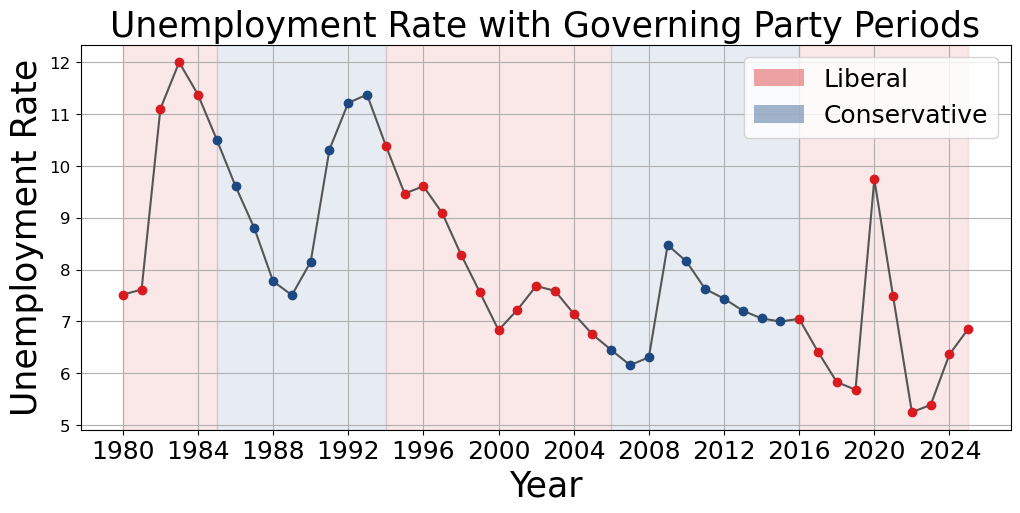

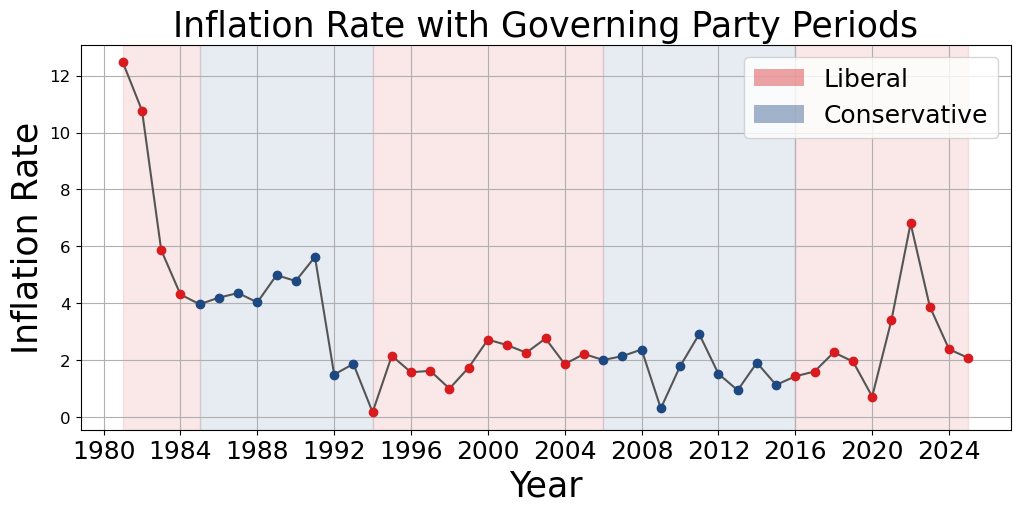

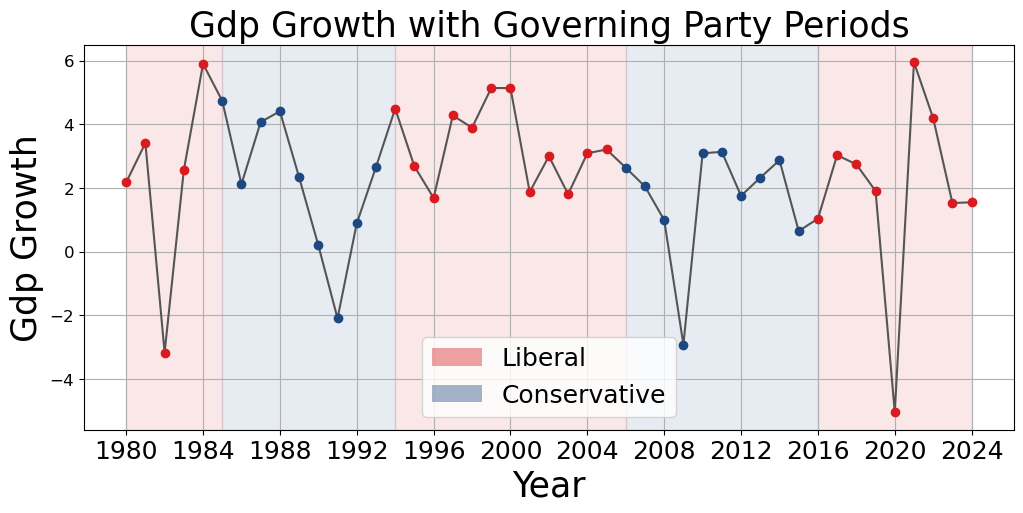

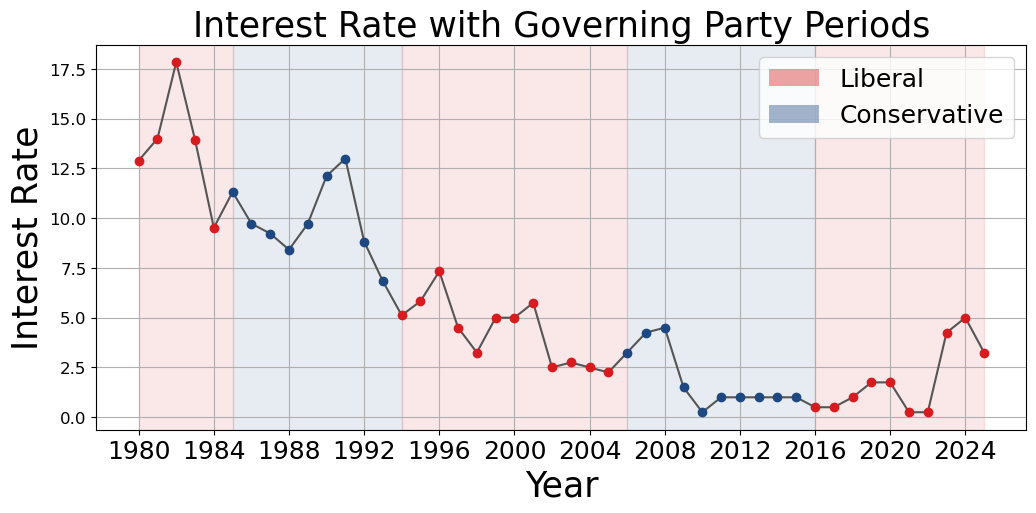

In [13]:
# Plot outcomes
for var in outcomes:
    temp = df[["year", var, "party_code"]].dropna().copy()

    # Color the scatterplots
    plt.figure(figsize=(12, 5))
    for party, x in temp.groupby("party_code"):
        color = PARTY_COLOR_MAP[party]
        plt.scatter(x["year"], x[var], color=color, label=party, zorder=5)
    plt.plot(temp["year"], temp[var], color=NEUTRAL_COLOR, zorder=3)

    # Shade party periods between transitions
    prev_party, start_year = temp.iloc[0]["party_code"], temp.iloc[0]["year"]
    for _, row in temp.iterrows():
        if row["party_code"] != prev_party:
            color = PARTY_COLOR_MAP[prev_party]
            plt.axvspan(start_year, row["year"], alpha=0.10, color=color)
            prev_party, start_year = row["party_code"], row["year"]
    color = PARTY_COLOR_MAP[prev_party]
    plt.axvspan(start_year, temp["year"].max(), alpha=0.10, color=color)
    plt.legend(handles=PARTY_LEGEND, fontsize=18)

    plt.title(f"{var.replace('_', ' ').title()} with Governing Party Periods", fontsize=25)
    plt.xticks(YEAR_X_TICKS, fontsize=18)
    plt.yticks(fontsize=12)
    plt.xlabel("Year", fontsize=25)
    plt.ylabel(var.replace("_", " ").title(), fontsize=25)
    plt.grid(True)
    plt.show()

# 16. Visualization: Box Plots by Party

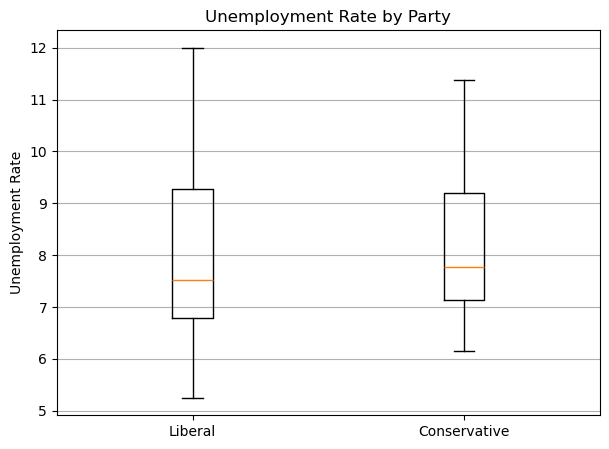

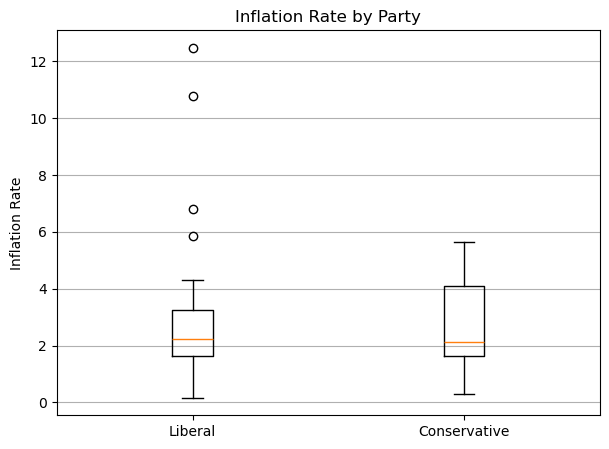

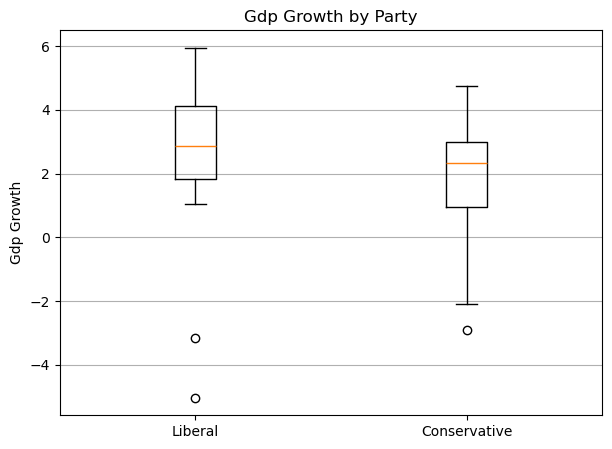

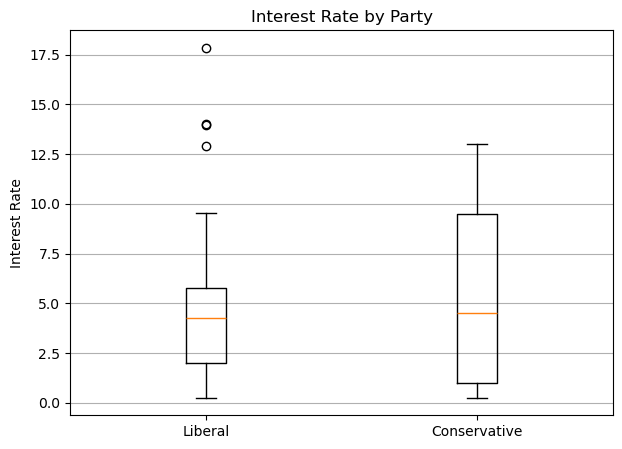

In [14]:
for var in outcomes:
    liberal = df.loc[df["party_code"] == LIBERAL_CODE, var].dropna()
    conservative = df.loc[df["party_code"] == CONSERVATIVE_CODE, var].dropna()

    plt.figure(figsize=(7, 5))
    plt.boxplot([liberal, conservative], tick_labels=[LIBERAL_NAME, CONSERVATIVE_NAME])
    plt.title(f"{var.replace('_', ' ').title()} by Party")
    plt.ylabel(var.replace("_", " ").title())
    plt.grid(True, axis="y")
    plt.show()

# 17. Visualization: Histograms for Outcome Distributions

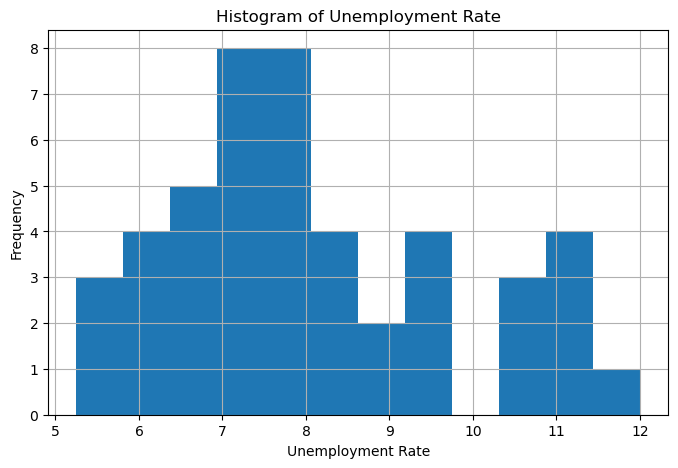

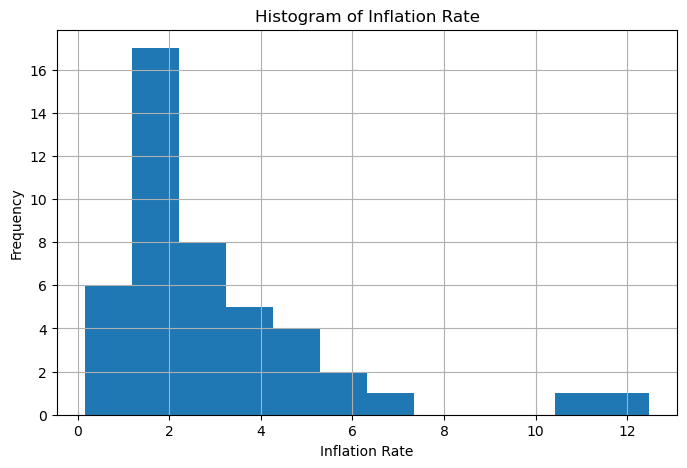

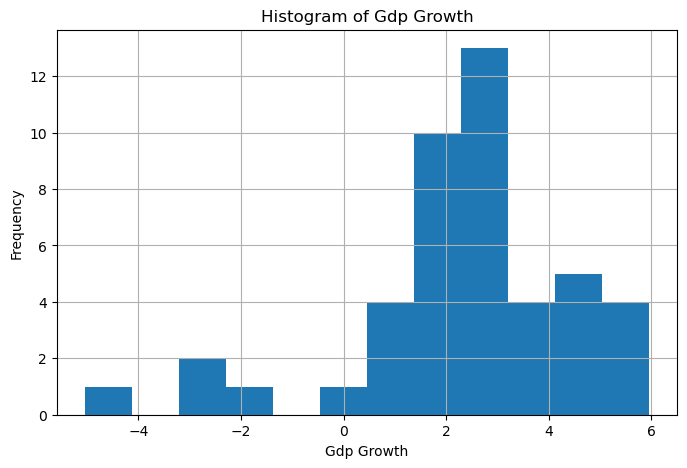

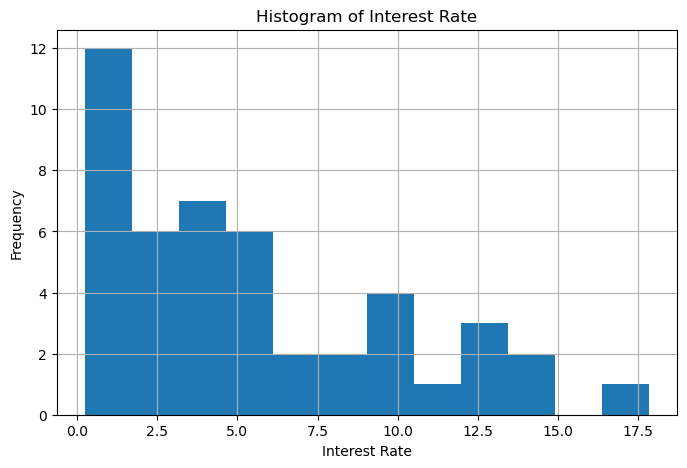

In [15]:
for var in outcomes:
    plt.figure(figsize=(8, 5))
    plt.hist(df[var].dropna(), bins=12)
    plt.title(f"Histogram of {var.replace('_', ' ').title()}")
    plt.xlabel(var.replace("_", " ").title())
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

# 18. Helper Functions for Statistical Analysis

In [16]:
def cohen_d(x, y):
    """
    Calculate Cohen's d for two arrays.
    """
    x = np.asarray(pd.Series(x).dropna(), dtype=float)
    y = np.asarray(pd.Series(y).dropna(), dtype=float)
    nx, ny = len(x), len(y)
    if nx < 2 or ny < 2:
        return np.nan
    pooled_sd = np.sqrt(((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1)) / (nx + ny - 2))
    if pooled_sd == 0:
        return np.nan
    return (np.mean(x) - np.mean(y)) / pooled_sd

def cohen_d_effect(d):
    """
    Describe Cohen's d significance.
    """
    d = abs(d)
    match d:
        case d if d < 0.2:
            mag = "negligible"
        case d if d < 0.5:
            mag = "small"
        case d if d < 0.8:
            mag = "medium"
        case _:
            mag = "large"
    return mag

def rank_biserial_from_mannwhitney(x, y):
    x = np.asarray(pd.Series(x).dropna(), dtype=float)
    y = np.asarray(pd.Series(y).dropna(), dtype=float)
    if len(x) == 0 or len(y) == 0:
        return np.nan
    u_stat, _ = mannwhitneyu(x, y, alternative="two-sided")
    return 1 - (2 * u_stat) / (len(x) * len(y))

def bootstrap_mean_diff(x, y, n_boot=5000, ci=95):
    x = np.asarray(pd.Series(x).dropna(), dtype=float)
    y = np.asarray(pd.Series(y).dropna(), dtype=float)
    boot_diffs = []
    for _ in range(n_boot):
        xb = np.random.choice(x, size=len(x), replace=True)
        yb = np.random.choice(y, size=len(y), replace=True)
        boot_diffs.append(np.mean(xb) - np.mean(yb))
    lower = np.percentile(boot_diffs, (100 - ci) / 2)
    upper = np.percentile(boot_diffs, 100 - (100 - ci) / 2)
    return np.mean(x) - np.mean(y), lower, upper, np.array(boot_diffs)

def permutation_test_mean_diff(x, y, n_perm=10000):
    x = np.asarray(pd.Series(x).dropna(), dtype=float)
    y = np.asarray(pd.Series(y).dropna(), dtype=float)
    observed = np.mean(x) - np.mean(y)
    combined = np.concatenate([x, y])
    nx = len(x)
    perm_diffs = np.empty(n_perm)
    for i in range(n_perm):
        perm = np.random.permutation(combined)
        perm_diffs[i] = np.mean(perm[:nx]) - np.mean(perm[nx:])
    p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed))
    return observed, p_value, perm_diffs

def chow_test(data, formula, split_index):
    # split_index is row count split after sorting by year
    d1 = data.iloc[:split_index].copy()
    d2 = data.iloc[split_index:].copy()

    m_all = smf.ols(formula, data=data).fit()
    m1 = smf.ols(formula, data=d1).fit()
    m2 = smf.ols(formula, data=d2).fit()

    rss_pooled = np.sum(m_all.resid ** 2)
    rss_1 = np.sum(m1.resid ** 2)
    rss_2 = np.sum(m2.resid ** 2)

    k = int(m_all.df_model) + 1
    n1 = d1.shape[0]
    n2 = d2.shape[0]

    numerator = (rss_pooled - (rss_1 + rss_2)) / k
    denominator = (rss_1 + rss_2) / (n1 + n2 - 2 * k)
    F = numerator / denominator
    p_value = 1 - stats.f.cdf(F, k, n1 + n2 - 2 * k)
    return F, p_value

# 19. Descriptive Statistics by Party

In [17]:
party_summary = df.groupby("party_full")[outcomes].agg(["mean", "median", "std", "count"])
display(party_summary)

unemployment_rate                           inflation_rate                           gdp_growth                           interest_rate                       
                          mean    median       std count           mean    median       std count       mean    median       std count          mean median       std count
party_full                                                                                                                                                                 
Conservative          8.270614  7.775000  1.623079    19       2.751123  2.138384  1.558770    19   1.891605  2.325814  1.971274    19      5.681579   4.50  4.451942    19
Liberal               7.901235  7.516667  1.846643    27       3.171891  2.235973  2.886394    26   2.619119  2.871109  2.418034    26      5.128889   4.25  4.680928    27

# 20. Welch t-Tests for All Outcomes

Welch's t-test compares mean differences without assuming equal variance.

In [18]:
ttest_results = []

for var in outcomes:
    lib = df.loc[df["party_code"] == LIBERAL_CODE, var].dropna()
    con = df.loc[df["party_code"] == CONSERVATIVE_CODE, var].dropna()

    t_stat, p_val = stats.ttest_ind(lib, con, equal_var=False)
    ttest_results.append({
        "outcome": var,
        "liberal_mean": lib.mean(),
        "conservative_mean": con.mean(),
        "mean_diff_L_minus_C": lib.mean() - con.mean(),
        "t_stat": t_stat,
        "p_value": p_val
    })

ttest_df = pd.DataFrame(ttest_results)
display(ttest_df)

,outcome,liberal_mean,conservative_mean,mean_diff_L_minus_C,t_stat,p_value
0,unemployment_rate,7.901235,8.270614,-0.369379,-0.717612,0.476993
1,inflation_rate,3.171891,2.751123,0.420768,0.628422,0.533293
2,gdp_growth,2.619119,1.891605,0.727514,1.110220,0.273158
3,interest_rate,5.128889,5.681579,-0.552690,-0.405834,0.687022


# One-Way ANOVA for All Outcomes

ANOVA tests whether group means differ.

Here, because there are mostly two main parties in the dataset, ANOVA and t-tests will often tell a similar story.
If additional party labels appear, ANOVA becomes more useful.

In [19]:
anova_results = []

for var in outcomes:
    groups = [g[var].dropna().values for _, g in df.groupby("party_label") if g[var].dropna().shape[0] > 1]
    labels = [name for name, g in df.groupby("party_label") if g[var].dropna().shape[0] > 1]

    if len(groups) >= 2:
        f_stat, p_val = stats.f_oneway(*groups)
    else:
        f_stat, p_val = np.nan, np.nan

    anova_results.append({
        "outcome": var,
        "groups_used": ", ".join(labels),
        "F_stat": f_stat,
        "p_value": p_val
    })

anova_df = pd.DataFrame(anova_results)
display(anova_df)

,outcome,groups_used,F_stat,p_value
0,unemployment_rate,"Conservative, Liberal",0.491994,0.486733
1,inflation_rate,"Conservative, Liberal",0.331618,0.567710
2,gdp_growth,"Conservative, Liberal",1.156039,0.288285
3,interest_rate,"Conservative, Liberal",0.161792,0.689460


# 21. Effect Sizes for Group Differences

- **Cohen's d** for mean difference size
- **rank-biserial correlation** from Mann–Whitney

In [20]:
effect_results = []

for var in outcomes:
    lib = df.loc[df["party_code"] == LIBERAL_CODE, var].dropna()
    con = df.loc[df["party_code"] == CONSERVATIVE_CODE, var].dropna()

    cohens_d_value = cohen_d(lib, con)
    effect_results.append({
        "outcome": var,
        "cohens_d_L_minus_C": cohens_d_value,
        "cohens_d_effect": cohen_d_effect(cohens_d_value),
        "rank_biserial": rank_biserial_from_mannwhitney(lib, con)
    })

effect_df = pd.DataFrame(effect_results)
display(effect_df)

,outcome,cohens_d_L_minus_C,cohens_d_effect,rank_biserial
0,unemployment_rate,-0.210039,small,0.157895
1,inflation_rate,0.173805,negligible,-0.004049
2,gdp_growth,0.324511,small,-0.255061
3,interest_rate,-0.120448,negligible,0.058480


# 22. Bootstrap Confidence Intervals for Mean Differences

Estimate a bootstrap confidence interval for the mean difference:
**Liberal mean minus Conservative mean**.

In [21]:
bootstrap_results = []
boot_store = {}

for var in outcomes:
    lib = df.loc[df["party_code"] == LIBERAL_CODE, var].dropna()
    con = df.loc[df["party_code"] == CONSERVATIVE_CODE, var].dropna()

    observed, lower, upper, boot_dist = bootstrap_mean_diff(lib, con, n_boot=5000)
    boot_store[var] = boot_dist

    bootstrap_results.append({
        "outcome": var,
        "observed_mean_diff_L_minus_C": observed,
        "bootstrap_ci_lower": lower,
        "bootstrap_ci_upper": upper
    })

bootstrap_df = pd.DataFrame(bootstrap_results)
display(bootstrap_df)

,outcome,observed_mean_diff_L_minus_C,bootstrap_ci_lower,bootstrap_ci_upper
0,unemployment_rate,-0.369379,-1.367031,0.618975
1,inflation_rate,0.420768,-0.840690,1.794751
2,gdp_growth,0.727514,-0.571071,1.964301
3,interest_rate,-0.552690,-3.075714,2.016026


# 23. Visualization: Bootstrap Distributions

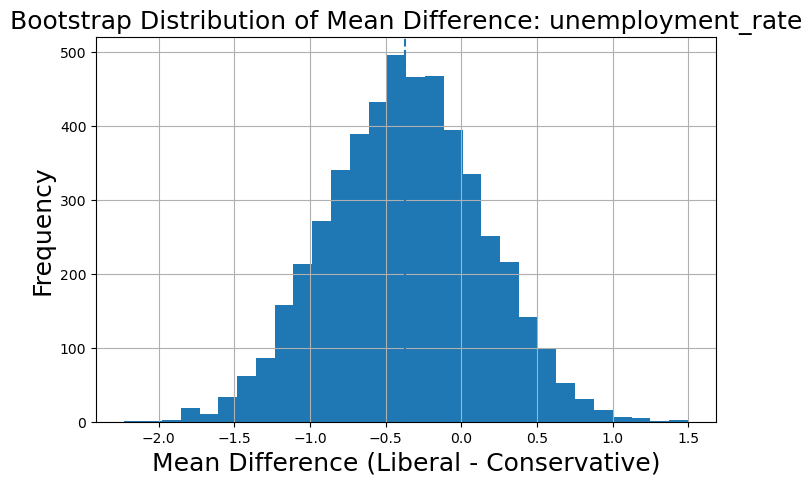

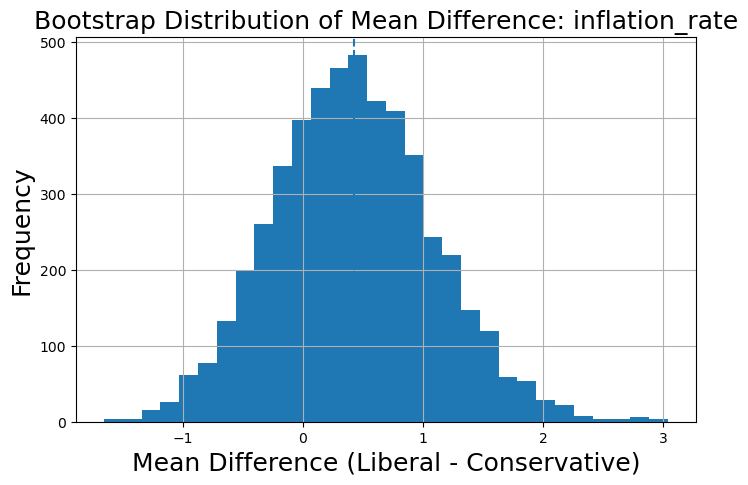

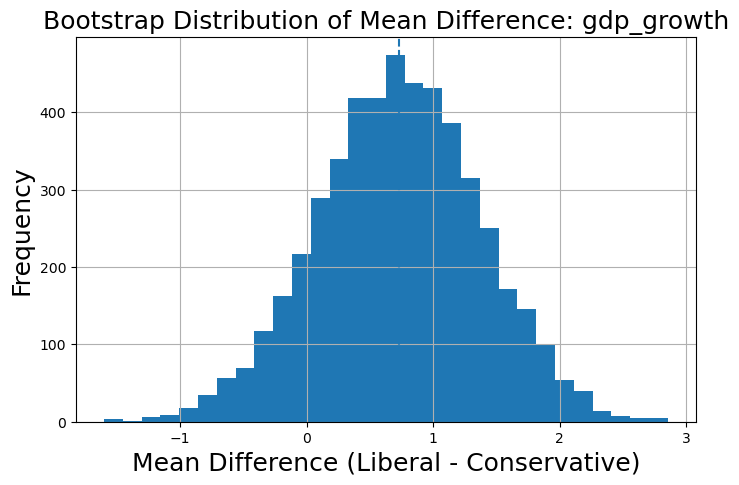

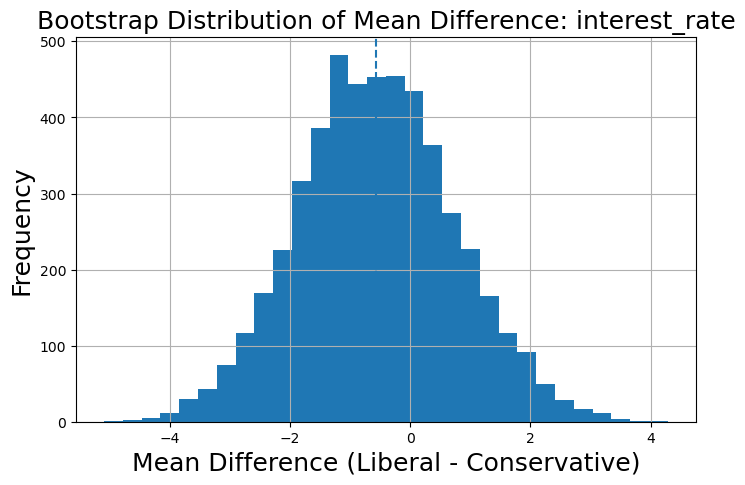

In [22]:
for var in outcomes:
    plt.figure(figsize=(8, 5))
    plt.hist(boot_store[var], bins=30)
    plt.axvline(np.mean(boot_store[var]), linestyle="--")
    plt.title(f"Bootstrap Distribution of Mean Difference: {var}",fontsize=18)
    plt.xlabel("Mean Difference (Liberal - Conservative)",fontsize=18)
    plt.ylabel("Frequency", fontsize=18)
    plt.grid(True)
    plt.show()

### Boostrap Result Analysis
Bootstrap resampling was used to assess the stability and uncertainty of the estimated differences in economic outcomes between political parties.

The bootstrap distribution was generated by repeatedly resampling the observed data with replacement and computing the mean difference between Liberal and Conservative periods.

The resulting confidence intervals for most outcomes include zero, indicating that the estimated differences are not statistically robust. This suggests that the observed differences may be sensitive to sampling variability and are not consistently reproducible across resampled datasets.

Furthermore, the relatively wide confidence intervals indicate a high degree of uncertainty, likely due to limited sample size and the influence of extreme economic events such as the financial crisis and the COVID-19 pandemic.

Overall, the bootstrap analysis reinforces the conclusion that there is no strong evidence of a stable difference in economic outcomes attributable to political party.

# 24. Permutation Tests for Mean Differences

Permutation tests do not rely on parametric assumptions in the same way as t-tests.

In [23]:
perm_results = []
perm_store = {}

for var in outcomes:
    lib = df.loc[df["party_code"] == LIBERAL_CODE, var].dropna()
    con = df.loc[df["party_code"] == CONSERVATIVE_CODE, var].dropna()

    observed, p_val, perm_dist = permutation_test_mean_diff(lib, con, n_perm=10000)
    perm_store[var] = perm_dist

    perm_results.append({
        "outcome": var,
        "observed_mean_diff_L_minus_C": observed,
        "permutation_p_value": p_val
    })

perm_df = pd.DataFrame(perm_results)
display(perm_df)

,outcome,observed_mean_diff_L_minus_C,permutation_p_value
0,unemployment_rate,-0.369379,0.4851
1,inflation_rate,0.420768,0.5804
2,gdp_growth,0.727514,0.2903
3,interest_rate,-0.552690,0.6906


# 25. Visualization: Permutation Distributions

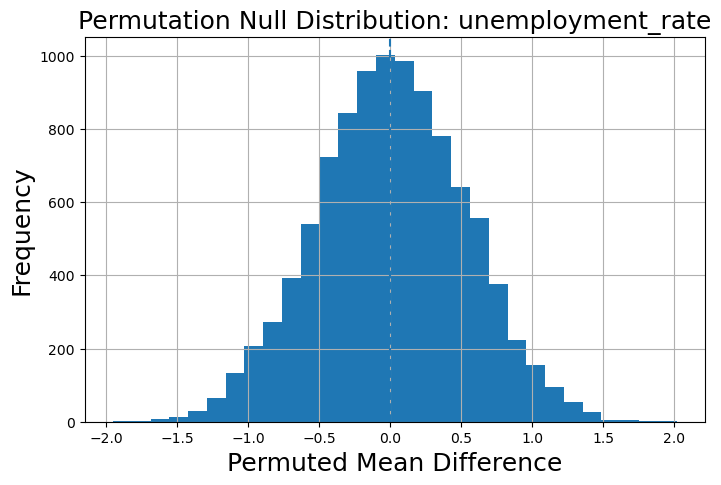

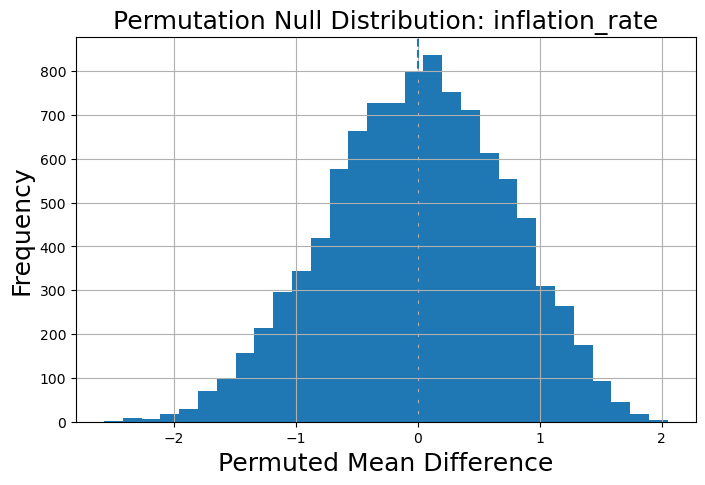

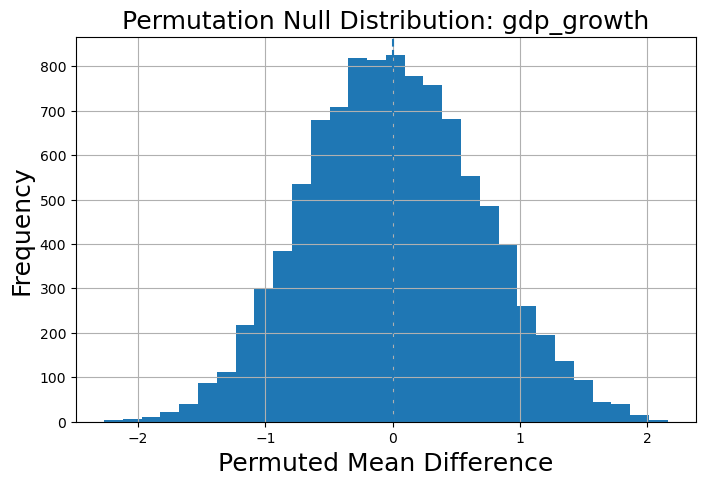

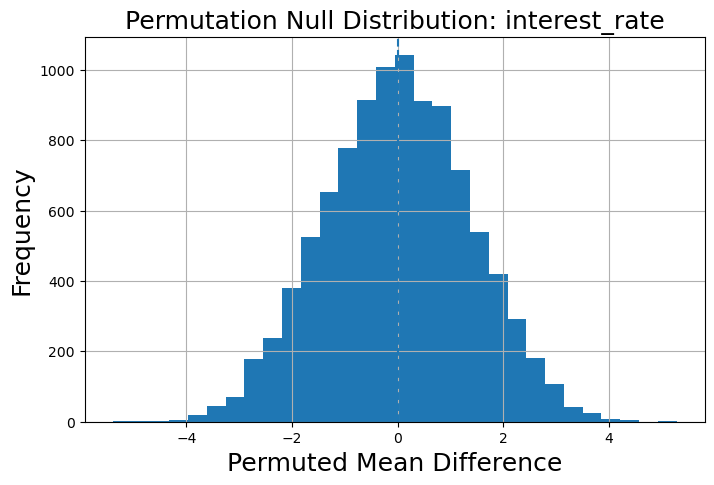

In [24]:
for var in outcomes:
    plt.figure(figsize=(8, 5))
    plt.hist(perm_store[var], bins=30)
    plt.axvline(0, linestyle="--")
    plt.title(f"Permutation Null Distribution: {var}",fontsize=18)
    plt.xlabel("Permuted Mean Difference",fontsize=18)
    plt.ylabel("Frequency",fontsize=18)
    plt.grid(True)
    plt.show()

### Permutation Test Analysis

A permutation test was conducted to evaluate whether the observed differences in economic outcomes between political parties could have occurred by random chance.

The test was performed by randomly reassigning party labels across observations and recalculating the mean difference between groups for a large number of iterations. This process generates a null distribution representing the expected variation in mean differences under the assumption that political party has no effect.

The p-value was computed as the proportion of simulated differences that were as extreme as or more extreme than the observed difference.

For most economic indicators, the permutation p-values were relatively large, indicating that the observed differences fall well within the range expected under random variation. This suggests that the differences between political parties are not statistically distinguishable from chance.

These findings reinforce the results obtained from t-tests and bootstrap analysis, providing additional evidence that political party does not have a strong measurable impact on economic outcomes in this dataset.

# 26. Correlation Matrix

This shows linear associations among outcomes and selected explanatory variables.

In [25]:
corr_vars = outcomes + ["party_binary", "ideology", "covid", "gfc", "ukraine_war", "us_admin_change", "trend"]
corr_matrix = df[corr_vars].corr()
display(corr_matrix)

,unemployment_rate,inflation_rate,gdp_growth,interest_rate,party_binary,ideology,covid,gfc,ukraine_war,us_admin_change,trend
unemployment_rate,1.000000,0.162327,-0.147250,0.598273,-0.105157,-0.105157,-0.085849,-0.081621,-0.372410,-0.177668,-0.675569
inflation_rate,0.162327,1.000000,-0.033202,0.705929,0.087482,0.087482,0.072462,-0.150642,0.103829,-0.069656,-0.478247
gdp_growth,-0.147250,-0.033202,1.000000,-0.133227,0.161805,0.161805,-0.073592,-0.317735,0.013508,-0.051399,-0.114538
interest_rate,0.598273,0.705929,-0.133227,1.000000,-0.060528,-0.060528,-0.270666,-0.111777,-0.148927,-0.058430,-0.850902
party_binary,-0.105157,0.087482,0.161805,-0.060528,1.000000,1.000000,0.221575,-0.254152,0.258881,0.178848,0.138015
ideology,-0.105157,0.087482,0.161805,-0.060528,1.000000,1.000000,0.221575,-0.254152,0.258881,0.178848,0.138015
covid,-0.085849,0.072462,-0.073592,-0.270666,0.221575,0.221575,1.000000,-0.056314,0.230956,-0.056314,0.368073
gfc,-0.081621,-0.150642,-0.317735,-0.111777,-0.254152,-0.254152,-0.056314,1.000000,-0.065795,-0.045455,0.096355
ukraine_war,-0.372410,0.103829,0.013508,-0.148927,0.258881,0.258881,0.230956,-0.065795,1.000000,0.690849,0.488158
us_admin_change,-0.177668,-0.069656,-0.051399,-0.058430,0.178848,0.178848,-0.056314,-0.045455,0.690849,1.000000,0.353303


# 27. Visualization: Correlation Heatmap-Style Plot

This uses plain matplotlib so it runs in a standard notebook environment.

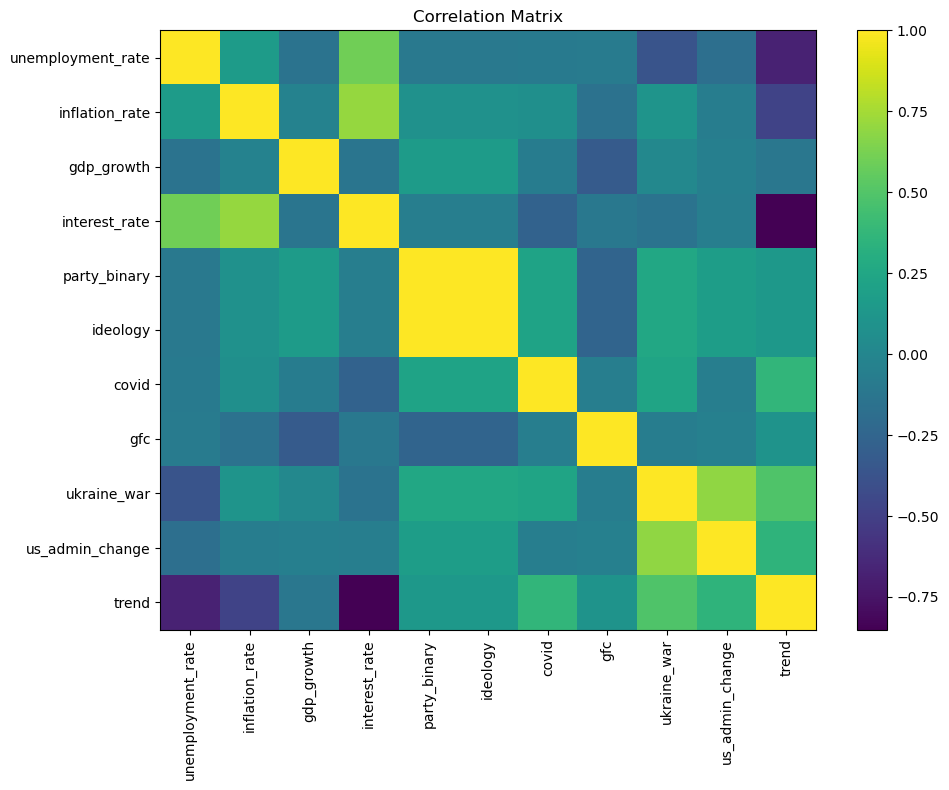

In [26]:
plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

### Correlation Matrix Analysis

A correlation matrix was constructed to examine the relationships among the key economic variables and control factors.

The results show expected macroeconomic relationships, such as a negative correlation between GDP growth and unemployment, and a positive correlation between inflation and interest rates. These relationships are consistent with standard economic theory.

In contrast, the correlation between the political party variable and the economic indicators is generally weak, suggesting that there is no strong linear association between party leadership and economic outcomes.

Additionally, strong correlations were observed among some explanatory variables, particularly between macroeconomic indicators and time trends. This indicates the presence of multicollinearity, which may affect the stability of regression coefficients but does not invalidate the overall analysis.

Overall, the correlation matrix supports the conclusion that economic outcomes are more strongly related to macroeconomic dynamics and external shocks than to political party alone.

# 28. Normality Tests

Test normality for each outcome using:
- Shapiro–Wilk
- Jarque–Bera

In [27]:
normality_results = []

for var in outcomes:
    series = df[var].dropna()

    # Shapiro can be unstable for very small or certain sample patterns, but is acceptable here
    sh_stat, sh_p = shapiro(series)
    jb_stat, jb_p = jarque_bera(series)

    normality_results.append({
        "outcome": var,
        "shapiro_stat": sh_stat,
        "shapiro_p_value": sh_p,
        "jarque_bera_stat": jb_stat,
        "jarque_bera_p_value": jb_p
    })

normality_df = pd.DataFrame(normality_results)
display(normality_df)

,outcome,shapiro_stat,shapiro_p_value,jarque_bera_stat,jarque_bera_p_value
0,unemployment_rate,0.936128,1.406924e-02,3.511816,1.727503e-01
1,inflation_rate,0.771883,6.048624e-07,95.177551,2.150094e-21
2,gdp_growth,0.896413,7.340537e-04,19.716849,5.230470e-05
3,interest_rate,0.899116,7.744687e-04,5.732419,5.691425e-02


# 29. Visualization: Q-Q Plots for Normality

<Figure size 600x600 with 0 Axes>

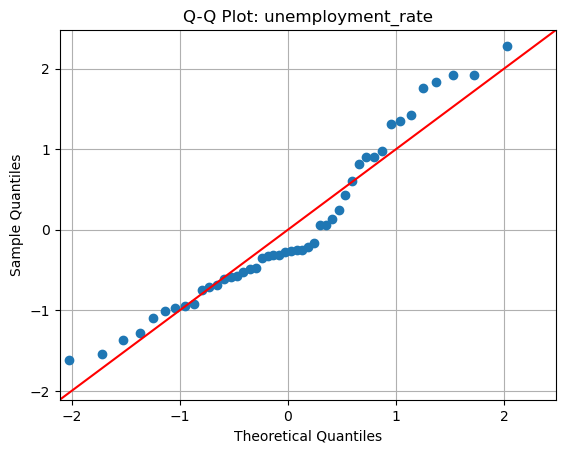

<Figure size 600x600 with 0 Axes>

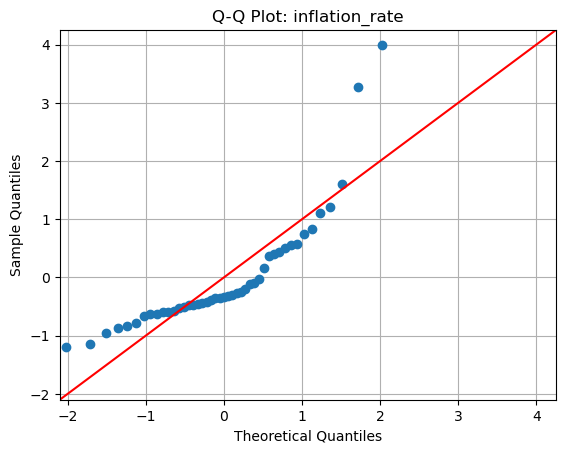

<Figure size 600x600 with 0 Axes>

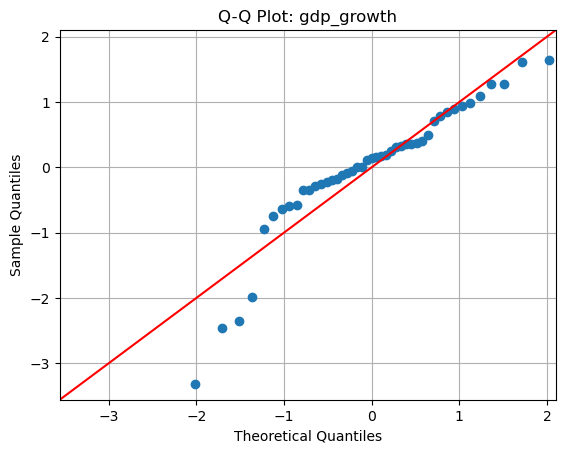

<Figure size 600x600 with 0 Axes>

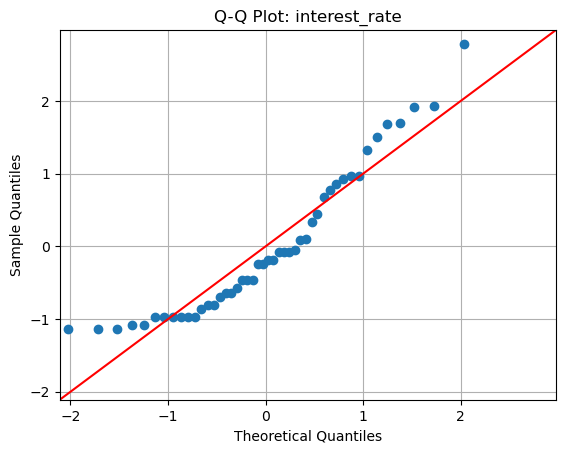

In [28]:
for var in outcomes:
    plt.figure(figsize=(6, 6))
    sm.qqplot(df[var].dropna(), line="45", fit=True)
    plt.title(f"Q-Q Plot: {var}")
    plt.grid(True)
    plt.show()

### Normality Test Analysis

Normality tests were conducted using the Shapiro–Wilk test and the Jarque–Bera test to assess whether the economic variables follow a normal distribution.

The results indicate that, for most variables, the null hypothesis of normality is rejected (p-value < 0.05). This suggests that the distributions deviate from the normal assumption.

This deviation is expected in macroeconomic data due to the presence of extreme events such as the 2008 global financial crisis and the COVID-19 pandemic, which introduce outliers and heavy tails into the distributions. Additionally, economic variables often exhibit skewness and structural breaks over time, further contributing to non-normality.

The Q-Q plots support these findings, showing noticeable deviations from the theoretical normal line, particularly in the tails of the distributions.

Despite the lack of normality, the analysis remains valid because robust statistical methods were used, including non-parametric tests, bootstrap resampling, and permutation testing, which do not rely on strict normality assumptions.

Overall, the results highlight that economic data are inherently non-normal due to the influence of external shocks and structural changes.

# 30. Outlier Detection Using Z-Scores

This flags years where the absolute z-score exceeds 2.5.

In [29]:
outlier_tables = {}

for var in outcomes:
    z = stats.zscore(df[var].dropna(), nan_policy="omit")
    temp = df.loc[df[var].notna(), ["year", "party_full", var]].copy()
    temp["z_score"] = z
    outliers = temp.loc[temp["z_score"].abs() > 2.5].copy()
    outlier_tables[var] = outliers

    print(f"\nOutliers for {var}")
    display(outliers)


Outliers for unemployment_rate


,year,party_full,unemployment_rate,z_score



Outliers for inflation_rate


,year,party_full,inflation_rate,z_score
1,1981,Liberal,12.471612,3.989430
2,1982,Liberal,10.768972,3.272716



Outliers for gdp_growth


,year,party_full,gdp_growth,z_score
40,2020,Liberal,-5.038233,-3.309765



Outliers for interest_rate


,year,party_full,interest_rate,z_score
2,1982,Liberal,17.84,2.77642


# 31. Visualization: Scatter Plots with Potential Outliers Highlighted (Remove since outliers cannot be deleted)

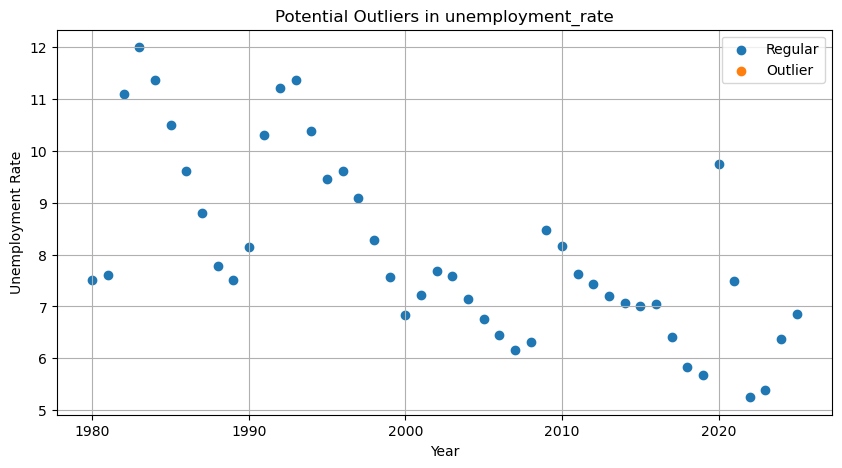

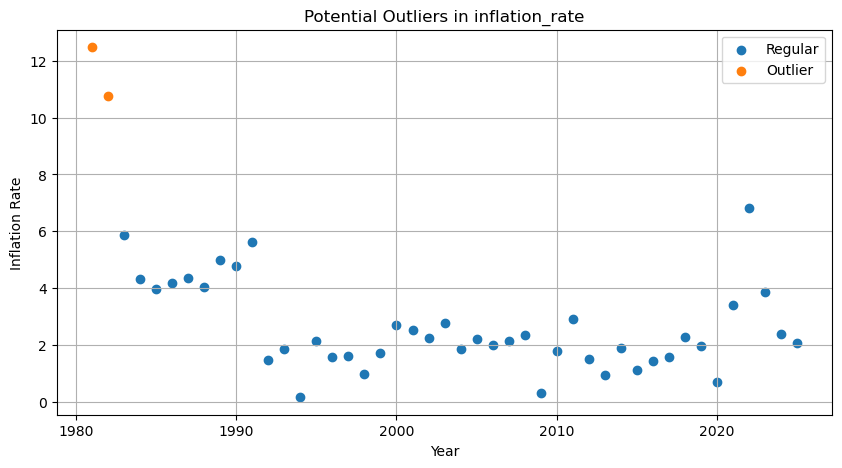

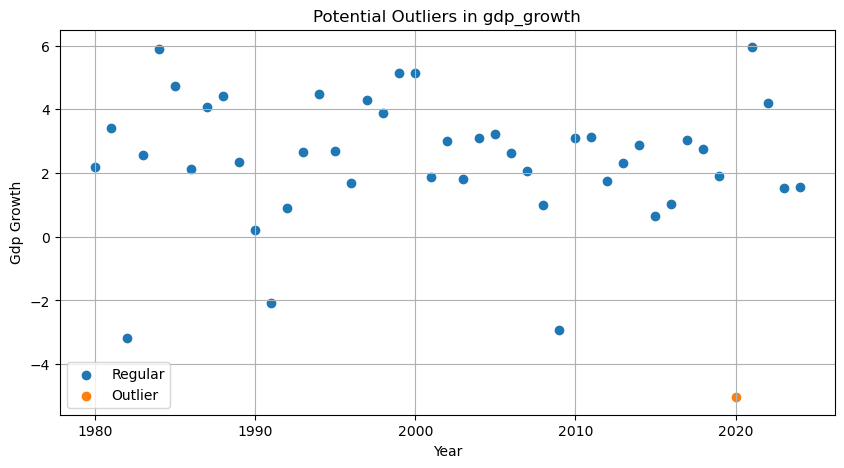

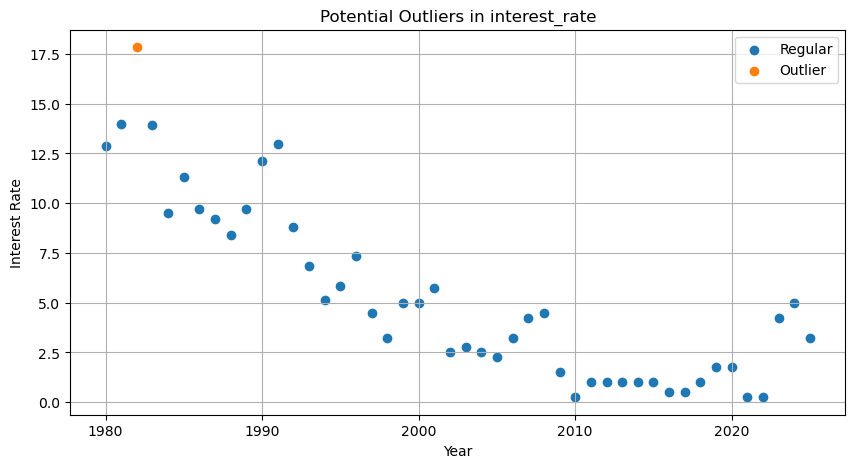

In [30]:
for var in outcomes:
    temp = df.loc[df[var].notna(), ["year", var]].copy()
    z = stats.zscore(temp[var], nan_policy="omit")
    temp["is_outlier"] = np.abs(z) > 2.5

    plt.figure(figsize=(10, 5))
    plt.scatter(temp.loc[~temp["is_outlier"], "year"], temp.loc[~temp["is_outlier"], var], label="Regular")
    plt.scatter(temp.loc[temp["is_outlier"], "year"], temp.loc[temp["is_outlier"], var], label="Outlier")
    plt.title(f"Potential Outliers in {var}")
    plt.xlabel("Year")
    plt.ylabel(var.replace("_", " ").title())
    plt.legend()
    plt.grid(True)
    plt.show()

### Outlier Detection Using Z-Scores

Outlier detection was performed using z-scores to identify observations that deviate significantly from the mean. A threshold of |z| > 2.5 was used to classify extreme values.

Several outliers were identified across the economic indicators. These extreme observations correspond to known macroeconomic events, such as the 2008 global financial crisis, the COVID-19 pandemic, and recent inflationary shocks associated with geopolitical events.

Importantly, these outliers do not represent data errors but rather reflect genuine economic disruptions. As such, they provide valuable information about the behavior of the economy under stress conditions.

Outliers can influence statistical analysis by distorting means, affecting regression estimates, and contributing to non-normality. However, removing these observations would eliminate critical information about real-world economic dynamics.

Instead of excluding outliers, the analysis accounts for their impact by incorporating control variables for major events and by using robust statistical methods, including bootstrap resampling and non-parametric tests.

Overall, the presence of outliers highlights the importance of external shocks in shaping economic outcomes and supports the need for careful interpretation of statistical results.

# 32. Baseline Regressions for All Outcomes

These regressions include party and key confounding factors.

In [31]:
regression_results = {}

for var in outcomes:
    temp = df.dropna(subset=[var]).copy()

    model = smf.ols(
        f"{var} ~ party_binary + covid + gfc + ukraine_war + us_admin_change + trend",
        data=temp
    ).fit(cov_type="HAC", cov_kwds={"maxlags": 1})

    regression_results[var] = model

    print(f"\nRegression for {var}")
    print(model.summary())


Regression for unemployment_rate
                            OLS Regression Results                            
Dep. Variable:      unemployment_rate   R-squared:                       0.531
Model:                            OLS   Adj. R-squared:                  0.458
Method:                 Least Squares   F-statistic:                     10.39
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           7.22e-07
Time:                        13:38:52   Log-Likelihood:                -73.078
No. Observations:                  46   AIC:                             160.2
Df Residuals:                      39   BIC:                             173.0
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercep

### Baseline Regression Analysis

A series of linear regression models were estimated to evaluate the relationship between political party and economic outcomes while controlling for major confounding factors.

The models include control variables representing key macroeconomic shocks, including the COVID-19 pandemic, the 2008 global financial crisis, the Ukraine–Russia war period, and changes in the U.S. policy environment. A time trend variable was also included to capture long-term structural changes in the economy.

Across all economic indicators, the coefficient associated with the political party variable is generally small and statistically insignificant. This suggests that, after accounting for major external shocks and long-term trends, there is no strong independent effect of political party on economic outcomes.

In contrast, variables representing major economic events, particularly the COVID-19 pandemic and the global financial crisis, exhibit strong and statistically significant effects. This indicates that macroeconomic conditions are heavily influenced by external shocks rather than domestic political leadership alone.

The time trend variable is also often statistically significant, reflecting underlying structural changes in the Canadian economy over the study period.

To improve the robustness of the results, heteroskedasticity and autocorrelation consistent (HAC) standard errors were used, accounting for potential time-series dependencies in the data.

Overall, the regression analysis provides strong evidence that economic performance is primarily driven by global events and structural trends, with limited measurable impact attributable to political party.

# 33. Compact Regression Coefficient Table

This extracts the main coefficient on party and selected controls for easier reading.

In [32]:
rows = []
for var, model in regression_results.items():
    for term in ["party_binary", "covid", "gfc", "ukraine_war", "us_admin_change", "trend"]:
        rows.append({
            "outcome": var,
            "term": term,
            "coef": model.params.get(term, np.nan),
            "p_value": model.pvalues.get(term, np.nan),
            "std_err": model.bse.get(term, np.nan)
        })

reg_coef_df = pd.DataFrame(rows)
display(reg_coef_df)

,outcome,term,coef,p_value,std_err
0,unemployment_rate,party_binary,-0.177801,7.079863e-01,0.474691
1,unemployment_rate,covid,1.924529,1.840539e-02,0.816392
2,unemployment_rate,gfc,-0.096059,8.719222e-01,0.595835
3,unemployment_rate,ukraine_war,-1.594842,1.027508e-02,0.621424
4,unemployment_rate,us_admin_change,2.447719,8.606994e-04,0.734500
5,unemployment_rate,trend,-0.096894,1.142052e-05,0.022080
6,inflation_rate,party_binary,0.273036,7.020332e-01,0.713675
7,inflation_rate,covid,2.023472,1.388822e-02,0.822502
8,inflation_rate,gfc,-0.299009,6.548793e-01,0.668933
9,inflation_rate,ukraine_war,4.387265,1.349344e-20,0.471533


# 34. Interaction Models: Party × Post-2020

This tests whether the party association changes after 2020.

In [33]:
interaction_results = {}

for var in outcomes:
    temp = df.dropna(subset=[var]).copy()

    model = smf.ols(
        f"{var} ~ party_binary * post_2020 + gfc + ukraine_war + us_admin_change + trend",
        data=temp
    ).fit(cov_type="HAC", cov_kwds={"maxlags": 1})

    interaction_results[var] = model

    print(f"\nInteraction model for {var}")
    print(model.summary())


Interaction model for unemployment_rate
                            OLS Regression Results                            
Dep. Variable:      unemployment_rate   R-squared:                       0.553
Model:                            OLS   Adj. R-squared:                  0.484
Method:                 Least Squares   F-statistic:                     42.29
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           1.43e-15
Time:                        13:38:52   Log-Likelihood:                -71.959
No. Observations:                  46   AIC:                             157.9
Df Residuals:                      39   BIC:                             170.7
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------

/Users/stuartthompson/miniconda3/envs/DataScience/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 7, but rank is 6
  warnings.warn('covariance of constraints does not have full '
/Users/stuartthompson/miniconda3/envs/DataScience/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 7, but rank is 6
  warnings.warn('covariance of constraints does not have full '
/Users/stuartthompson/miniconda3/envs/DataScience/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 7, but rank is 6
  warnings.warn('covariance of constraints does not have full '
/Users/stuartthompson/miniconda3/envs/DataScience/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of con

# 35. Interaction Models: Ideology × Trend

This tests whether the trend differs by ideological period.

In [34]:
trend_interaction_results = {}

for var in outcomes:
    temp = df.dropna(subset=[var]).copy()

    model = smf.ols(
        f"{var} ~ ideology * trend + covid + gfc + ukraine_war + us_admin_change",
        data=temp
    ).fit(cov_type="HAC", cov_kwds={"maxlags": 1})

    trend_interaction_results[var] = model

    print(f"\nIdeology × Trend model for {var}")
    print(model.summary())


Ideology × Trend model for unemployment_rate
                            OLS Regression Results                            
Dep. Variable:      unemployment_rate   R-squared:                       0.531
Model:                            OLS   Adj. R-squared:                  0.445
Method:                 Least Squares   F-statistic:                     9.125
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           1.44e-06
Time:                        13:38:52   Log-Likelihood:                -73.034
No. Observations:                  46   AIC:                             162.1
Df Residuals:                      38   BIC:                             176.7
Df Model:                           7                                         
Covariance Type:                  HAC                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------

# 36. Lagged Ideology Regressions

Policy effects may appear with a lag rather than immediately.

In [35]:
lagged_results = {}

for var in outcomes:
    temp = df.dropna(subset=[var, "ideology_lag1"]).copy()

    model = smf.ols(
        f"{var} ~ ideology_lag1 + covid + gfc + ukraine_war + us_admin_change + trend",
        data=temp
    ).fit(cov_type="HAC", cov_kwds={"maxlags": 1})

    lagged_results[var] = model

    print(f"\nLagged ideology model for {var}")
    print(model.summary())


Lagged ideology model for unemployment_rate
                            OLS Regression Results                            
Dep. Variable:      unemployment_rate   R-squared:                       0.590
Model:                            OLS   Adj. R-squared:                  0.525
Method:                 Least Squares   F-statistic:                     11.47
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           2.72e-07
Time:                        13:38:53   Log-Likelihood:                -68.893
No. Observations:                  45   AIC:                             151.8
Df Residuals:                      38   BIC:                             164.4
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------

# 37. Time Trend Models Only

These models show whether each outcome has a significant long-run trend, even without party controls.

In [36]:
for var in outcomes:
    temp = df.dropna(subset=[var]).copy()
    model = smf.ols(f"{var} ~ trend", data=temp).fit()
    print(f"\nTime trend only model for {var}")
    print(model.summary())


Time trend only model for unemployment_rate
                            OLS Regression Results                            
Dep. Variable:      unemployment_rate   R-squared:                       0.456
Model:                            OLS   Adj. R-squared:                  0.444
Method:                 Least Squares   F-statistic:                     36.94
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           2.59e-07
Time:                        13:38:53   Log-Likelihood:                -76.454
No. Observations:                  46   AIC:                             156.9
Df Residuals:                      44   BIC:                             160.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Interce

# 38. Sensitivity Analysis: Excluding Major Shock Years

Exclude:
- 2008 and 2009
- 2020, 2021, 2022

This checks whether results depend heavily on extreme periods.

In [37]:
df_sens = df[~df["year"].isin([2008, 2009, 2020, 2021, 2022])].copy()

sensitivity_results = {}

for var in outcomes:
    temp = df_sens.dropna(subset=[var]).copy()

    model = smf.ols(
        f"{var} ~ party_binary + ukraine_war + us_admin_change + trend",
        data=temp
    ).fit(cov_type="HAC", cov_kwds={"maxlags": 1})

    sensitivity_results[var] = model

    print(f"\nSensitivity model for {var}")
    print(model.summary())


Sensitivity model for unemployment_rate
                            OLS Regression Results                            
Dep. Variable:      unemployment_rate   R-squared:                       0.540
Model:                            OLS   Adj. R-squared:                  0.489
Method:                 Least Squares   F-statistic:                     57.83
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           3.52e-15
Time:                        13:38:53   Log-Likelihood:                -64.785
No. Observations:                  41   AIC:                             139.6
Df Residuals:                      36   BIC:                             148.1
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
I

/Users/stuartthompson/miniconda3/envs/DataScience/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 4, but rank is 3
  warnings.warn('covariance of constraints does not have full '


### Sensitivity Analysis: Excluding Major Shock Years

A sensitivity analysis was conducted to evaluate whether the results of the regression models are influenced by extreme macroeconomic events. Specifically, years corresponding to the 2008–2009 global financial crisis and the 2020–2022 COVID-19 pandemic were excluded from the dataset.

These periods represent significant economic disruptions and may disproportionately influence statistical results due to their extreme values and structural deviations from typical economic conditions.

The regression models were re-estimated using the reduced dataset, focusing on relatively stable economic periods. The results show that the coefficient associated with political party remains small and statistically insignificant, consistent with the findings from the full sample.

This indicates that the lack of a significant relationship between political party and economic outcomes is not driven solely by crisis periods. Instead, it reflects a broader pattern across both stable and volatile economic environments.

Overall, the sensitivity analysis confirms the robustness of the main results and supports the conclusion that political party does not have a strong independent effect on economic performance.

# 39. Sensitivity Analysis: Winsorized Outcomes

This optional analysis limits extreme values at the 5th and 95th percentiles.

In [38]:
df_win = df.copy()

for var in outcomes:
    lower = df_win[var].quantile(0.05)
    upper = df_win[var].quantile(0.95)
    df_win[f"{var}_win"] = df_win[var].clip(lower=lower, upper=upper)

for var in outcomes:
    temp = df_win.dropna(subset=[f"{var}_win"]).copy()
    model = smf.ols(
        f"{var}_win ~ party_binary + covid + gfc + ukraine_war + us_admin_change + trend",
        data=temp
    ).fit(cov_type="HAC", cov_kwds={"maxlags": 1})

    print(f"\nWinsorized regression for {var}")
    print(model.summary())


Winsorized regression for unemployment_rate
                              OLS Regression Results                             
Dep. Variable:     unemployment_rate_win   R-squared:                       0.521
Model:                               OLS   Adj. R-squared:                  0.447
Method:                    Least Squares   F-statistic:                     9.820
Date:                   Thu, 09 Apr 2026   Prob (F-statistic):           1.36e-06
Time:                           13:38:53   Log-Likelihood:                -71.903
No. Observations:                     46   AIC:                             157.8
Df Residuals:                         39   BIC:                             170.6
Df Model:                              6                                         
Covariance Type:                     HAC                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------

### Sensitivity Analysis: Winsorized Outcomes

A sensitivity analysis was conducted using winsorized versions of the economic outcome variables to assess whether extreme values influence the regression results.

Winsorization was applied by capping the lower and upper tails of each variable at predefined percentile thresholds (e.g., 5th and 95th percentiles). This approach preserves all observations while reducing the influence of extreme values.

The regression models were re-estimated using the winsorized variables. The results show that the coefficient associated with political party remains small and statistically insignificant, consistent with the baseline model.

This indicates that the findings are not driven by extreme observations, such as those occurring during major economic shocks like the financial crisis or the COVID-19 pandemic.

Overall, the winsorized analysis confirms the robustness of the main conclusions and suggests that the lack of a strong relationship between political party and economic outcomes is not an artifact of outliers or heavy-tailed distributions.

# 40. DiD-Style Event Specification

A classic DiD design needs a clear treatment group and control group.
Because this project is a single-country time series, a full causal DiD is not ideal.

Still, we can estimate a **DiD-style interaction** using ideology and a post period as an event-study style robustness check.

Interpret this as exploratory, not definitive causal evidence.

In [39]:
did_results = {}

for var in outcomes:
    temp = df.dropna(subset=[var]).copy()

    model = smf.ols(
        f"{var} ~ ideology + post_2020 + ideology:post_2020 + gfc + ukraine_war + us_admin_change + trend",
        data=temp
    ).fit(cov_type="HAC", cov_kwds={"maxlags": 1})

    did_results[var] = model

    print(f"\nDiD-style model for {var}")
    print(model.summary())


DiD-style model for unemployment_rate
                            OLS Regression Results                            
Dep. Variable:      unemployment_rate   R-squared:                       0.553
Model:                            OLS   Adj. R-squared:                  0.484
Method:                 Least Squares   F-statistic:                     42.29
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           1.43e-15
Time:                        13:38:53   Log-Likelihood:                -71.959
No. Observations:                  46   AIC:                             157.9
Df Residuals:                      39   BIC:                             170.7
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------

/Users/stuartthompson/miniconda3/envs/DataScience/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 7, but rank is 6
  warnings.warn('covariance of constraints does not have full '
/Users/stuartthompson/miniconda3/envs/DataScience/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 7, but rank is 6
  warnings.warn('covariance of constraints does not have full '
/Users/stuartthompson/miniconda3/envs/DataScience/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 7, but rank is 6
  warnings.warn('covariance of constraints does not have full '
/Users/stuartthompson/miniconda3/envs/DataScience/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of con

# 41. Visualization: Pre/Post 2020 by Ideology

This plot helps interpret the event-style interaction.

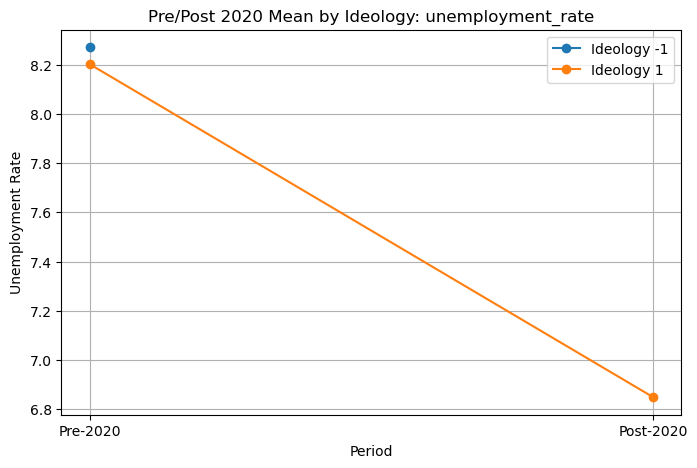

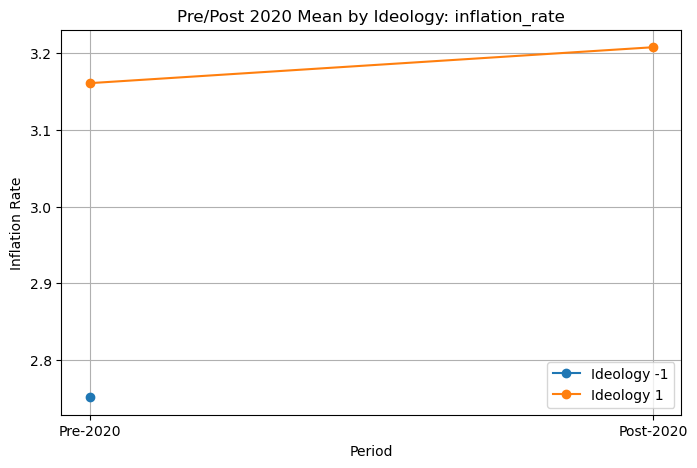

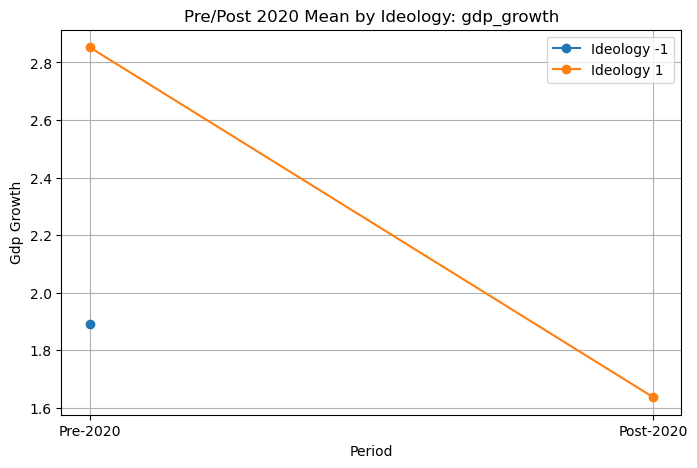

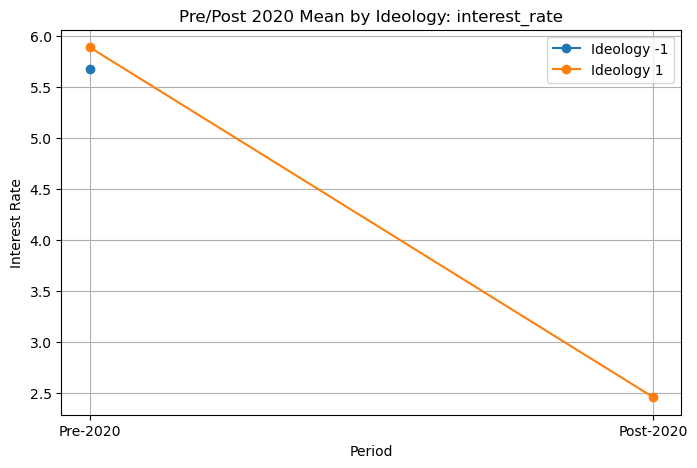

In [40]:
for var in outcomes:
    temp = df[["year", var, "ideology", "post_2020"]].dropna().copy()
    summary = temp.groupby(["ideology", "post_2020"])[var].mean().reset_index()

    plt.figure(figsize=(8, 5))
    for ideol in sorted(summary["ideology"].unique()):
        sub = summary[summary["ideology"] == ideol]
        plt.plot(sub["post_2020"], sub[var], marker="o", label=f"Ideology {ideol}")
    plt.xticks([0, 1], ["Pre-2020", "Post-2020"])
    plt.title(f"Pre/Post 2020 Mean by Ideology: {var}")
    plt.ylabel(var.replace("_", " ").title())
    plt.xlabel("Period")
    plt.legend()
    plt.grid(True)
    plt.show()

### Difference-in-Differences (DiD)-Style Event Analysis

A Difference-in-Differences (DiD)-style specification was used to examine whether economic outcomes responded differently to major shocks depending on the governing political ideology.

The model includes an interaction term between political ideology and a post-event indicator (e.g., post-2020 for the COVID-19 period). This interaction term captures whether the effect of the shock differs across political regimes.

The results show that while the post-event variable is often statistically significant, indicating a strong impact of major economic shocks, the interaction term between ideology and the post-event period is generally small and statistically insignificant.

This suggests that the response of economic outcomes to major shocks is largely similar across political parties, with no strong evidence that one party systematically mitigates or amplifies the effects of such events.

It is important to note that this analysis is based on a single-country time series and does not include a true control group. Therefore, the results should be interpreted as an event-study style analysis rather than a strict causal Difference-in-Differences design.

Overall, the findings reinforce the conclusion that external macroeconomic shocks play a dominant role in shaping economic outcomes, with limited differential impact attributable to political party.

# 42. Chow Test for Structural Break

We test whether there is a structural break at a chosen year.

Below, we test a break around **2020**, because COVID and later macro conditions may have changed relationships.

In [41]:
# Prepare sorted data
df_chow = df.dropna(subset=["gdp_growth", "party_binary", "trend"]).sort_values("year").copy()

# find split at first year >= 2020
split_idx = int(np.where(df_chow["year"].values >= 2020)[0][0])

for var in outcomes:
    temp = df.dropna(subset=[var, "party_binary", "trend"]).sort_values("year").copy()
    split_idx_var = int(np.where(temp["year"].values >= 2020)[0][0])

    F_stat, p_val = chow_test(temp, f"{var} ~ party_binary + trend", split_idx_var)

    print(f"{var}: Chow test at 2020")
    print("F statistic =", F_stat)
    print("p-value     =", p_val)
    print()

unemployment_rate: Chow test at 2020
F statistic = 1.2776864697216153
p-value     = 0.2950964284296842

inflation_rate: Chow test at 2020
F statistic = 2.7444675045174876
p-value     = 0.05595462320551292

gdp_growth: Chow test at 2020
F statistic = 0.679875325246696
p-value     = 0.5696731047183259

interest_rate: Chow test at 2020
F statistic = 9.457545596539914
p-value     = 7.541620727113951e-05



# 43. Chi-Square Test of Independence

A chi-square test needs categorical variables.
To apply it here, we convert each economic outcome into a categorical variable such as:

- above median
- below median

Then we test whether outcome category is independent of party.

This is a simplified categorical robustness check.

In [42]:
chi_results = []

for var in outcomes:
    temp = df[["party_full", var]].dropna().copy()
    temp["high_outcome"] = np.where(temp[var] >= temp[var].median(), "High", "Low")

    contingency = pd.crosstab(temp["party_full"], temp["high_outcome"])
    chi2, p_val, dof, expected = chi2_contingency(contingency)

    chi_results.append({
        "outcome": var,
        "chi2": chi2,
        "p_value": p_val,
        "dof": dof
    })

    print(f"\nContingency table for {var}")
    display(contingency)
    print("Expected counts")
    display(pd.DataFrame(expected, index=contingency.index, columns=contingency.columns))

chi_df = pd.DataFrame(chi_results)
display(chi_df)


Contingency table for unemployment_rate


high_outcome,High,Low
party_full,,
Conservative,11,8
Liberal,12,15


Expected counts


high_outcome,High,Low
party_full,,
Conservative,9.5,9.5
Liberal,13.5,13.5



Contingency table for inflation_rate


...


Contingency table for interest_rate


high_outcome,High,Low
party_full,,
Conservative,10,9
Liberal,13,14


Expected counts


high_outcome,High,Low
party_full,,
Conservative,9.5,9.5
Liberal,13.5,13.5


,outcome,chi2,p_value,dof
0,unemployment_rate,0.358674,0.549243,1
1,inflation_rate,0.016247,0.898572,1
2,gdp_growth,0.534722,0.464628,1
3,interest_rate,0.000000,1.000000,1


# 44. Additional Visualization: Scatter Plots Against Trend

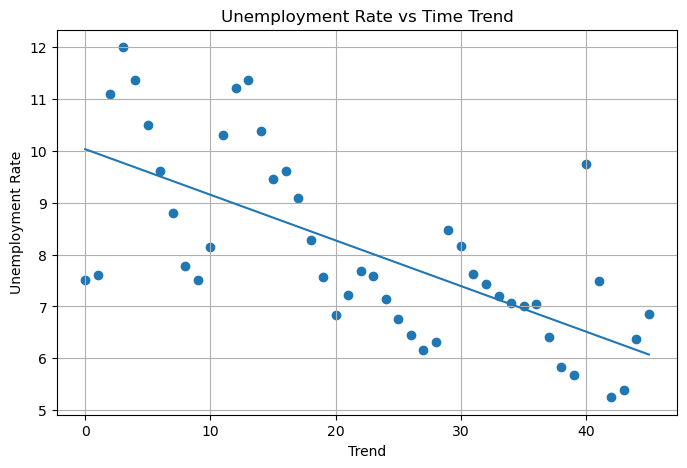

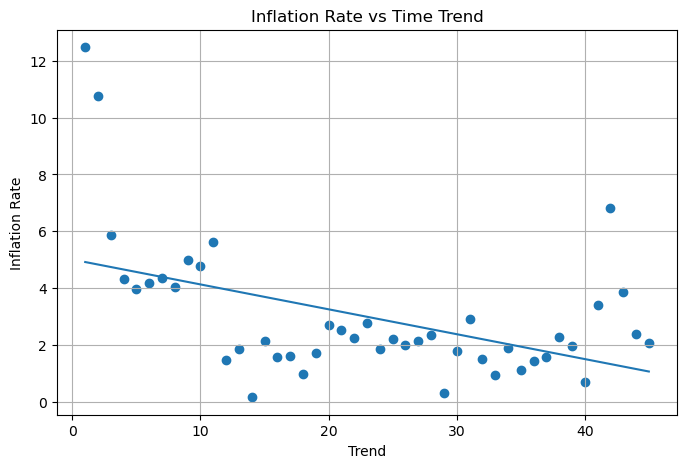

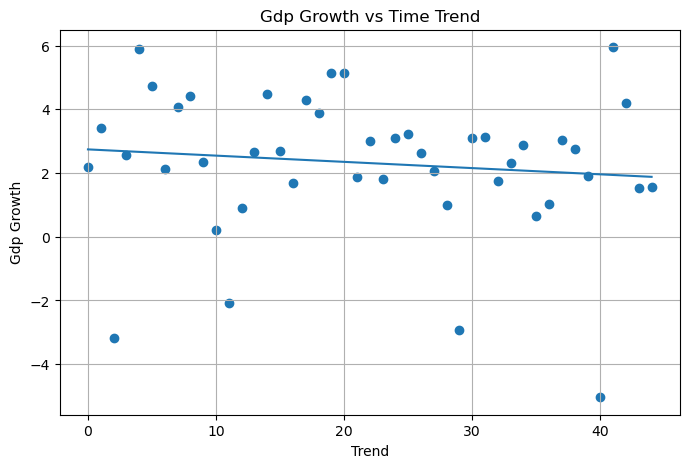

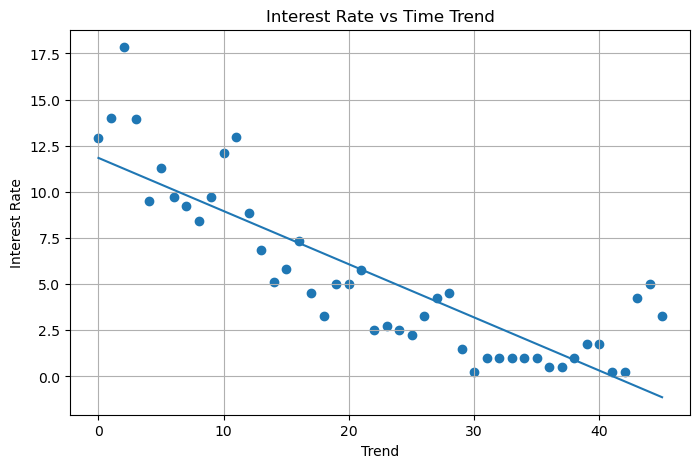

In [43]:
for var in outcomes:
    temp = df[["trend", var]].dropna()

    plt.figure(figsize=(8, 5))
    plt.scatter(temp["trend"], temp[var])

    z = np.polyfit(temp["trend"], temp[var], 1)
    p = np.poly1d(z)

    plt.plot(temp["trend"], p(temp["trend"]))
    plt.title(f"{var.replace('_', ' ').title()} vs Time Trend")
    plt.xlabel("Trend")
    plt.ylabel(var.replace("_", " ").title())
    plt.grid(True)
    plt.show()

# Additional Visualizations

The next few sections add more professional plots that help you understand the results more clearly.

These are especially useful because they translate statistical output into something visual and easier to interpret.

Add:

1. **Bootstrap confidence interval plot**  
2. **Regression coefficient plot**  
3. **Distribution comparison histograms by party**

These plots are often easier to discuss in a report or presentation than raw statistical tables.

# Bootstrap Confidence Interval Plot

Earlier in the notebook, we used bootstrap resampling to estimate confidence intervals for the mean difference between:

- Liberal years
- Conservative years

This plot turns those numbers into a picture.

## How to read it
- Each point is the estimated mean difference
- Each horizontal line is the bootstrap 95% confidence interval
- The vertical line at 0 means **no difference**

### Interpretation idea
If the interval crosses 0, then the difference may be too uncertain to claim clearly.

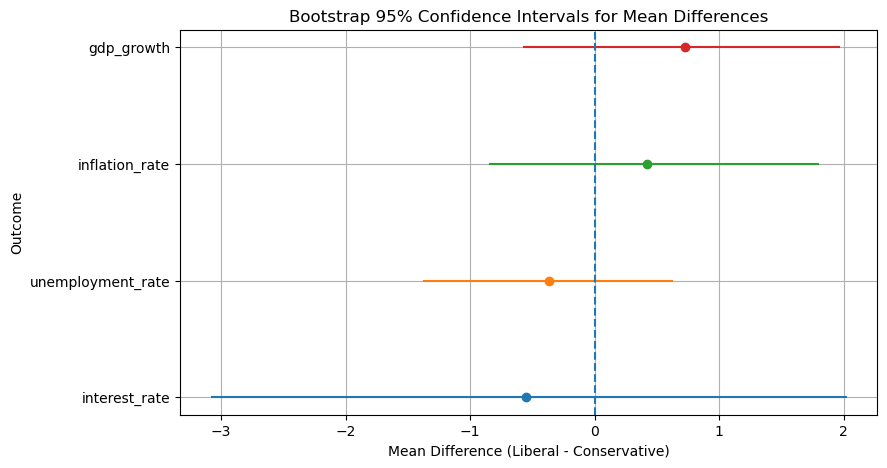

In [44]:
boot_plot_df = bootstrap_df.copy()
boot_plot_df = boot_plot_df.sort_values("observed_mean_diff_L_minus_C")

plt.figure(figsize=(9, 5))

for i, row in enumerate(boot_plot_df.itertuples(index=False)):
    plt.plot(
        [row.bootstrap_ci_lower, row.bootstrap_ci_upper],
        [i, i]
    )
    plt.scatter(row.observed_mean_diff_L_minus_C, i)

plt.axvline(0, linestyle="--")
plt.yticks(range(len(boot_plot_df)), boot_plot_df["outcome"])
plt.xlabel("Mean Difference (Liberal - Conservative)")
plt.ylabel("Outcome")
plt.title("Bootstrap 95% Confidence Intervals for Mean Differences")
plt.grid(True)
plt.show()

# Regression Coefficient Plot

Regression summary tables contain a lot of numbers, and beginners often find them hard to read.

This plot shows the estimated coefficients for the main predictors, along with approximate 95% confidence intervals.

## How to read it
- Each point is a coefficient estimate
- The horizontal bar shows uncertainty
- The vertical line at 0 means "no effect"

### Important interpretation
If a confidence interval clearly crosses 0, the evidence for that variable is weaker.

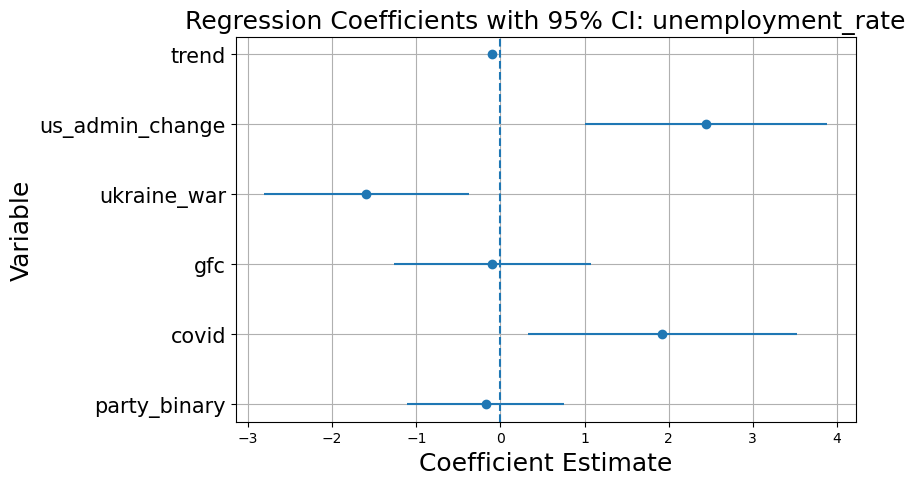

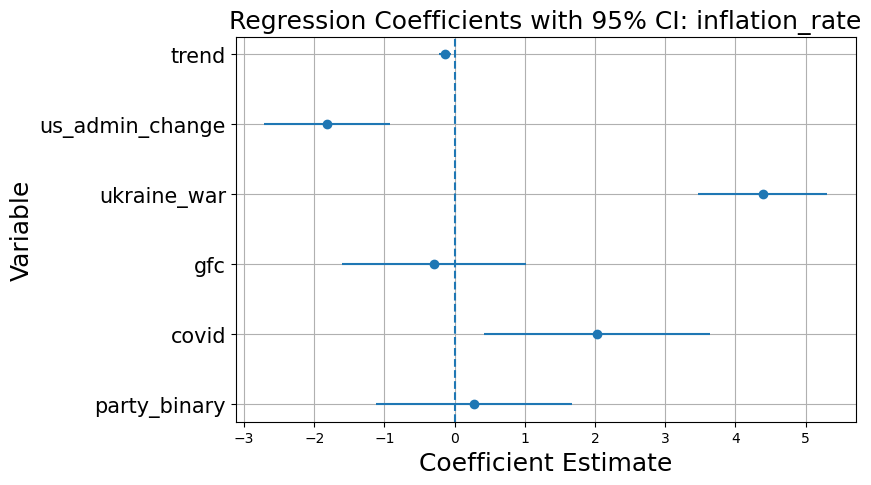

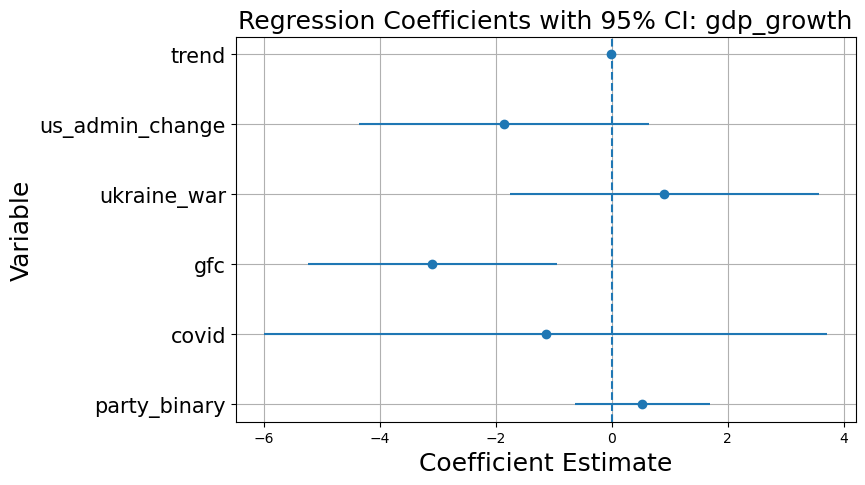

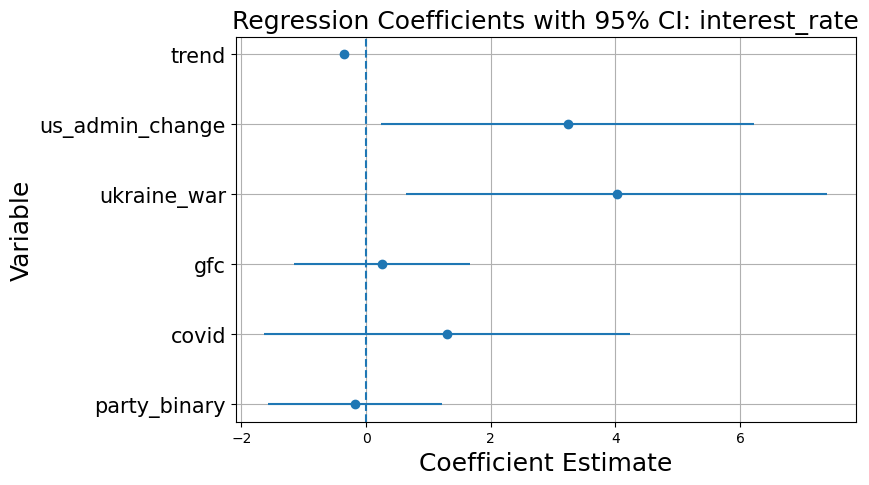

In [45]:
focus_terms = ["party_binary", "covid", "gfc", "ukraine_war", "us_admin_change", "trend"]

for var in outcomes:
    model = regression_results[var]

    coefs = []
    errors = []

    for term in focus_terms:
        coefs.append(model.params.get(term, float("nan")))
        errors.append(1.96 * model.bse.get(term, float("nan")))

    coef_df = pd.DataFrame({
        "term": focus_terms,
        "coef": coefs,
        "ci": errors
    }).dropna()

    plt.figure(figsize=(8, 5))
    plt.errorbar(coef_df["coef"], coef_df["term"], xerr=coef_df["ci"], fmt="o")
    plt.axvline(0, linestyle="--")
    plt.title(f"Regression Coefficients with 95% CI: {var}", fontsize=18)
    plt.xlabel("Coefficient Estimate",fontsize=18)
    plt.ylabel("Variable",fontsize=18)
    plt.yticks(fontsize=15)
    plt.grid(True)
    plt.show()

# Distribution Comparison by Party

This plot compares the distribution of each outcome under Liberal and Conservative periods.

## Why this helps
Even if the averages are similar, the **shape** of the distributions may differ.

For example:
- one party period may have more extreme values
- one may have more spread or volatility
- the two distributions may overlap heavily

Heavy overlap usually means the party difference is not visually strong.

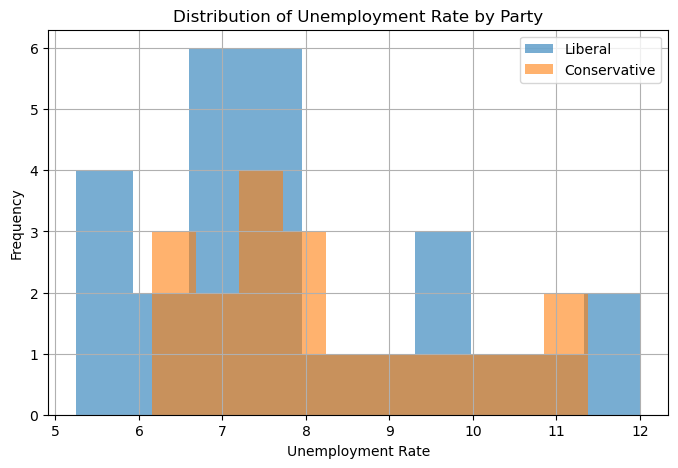

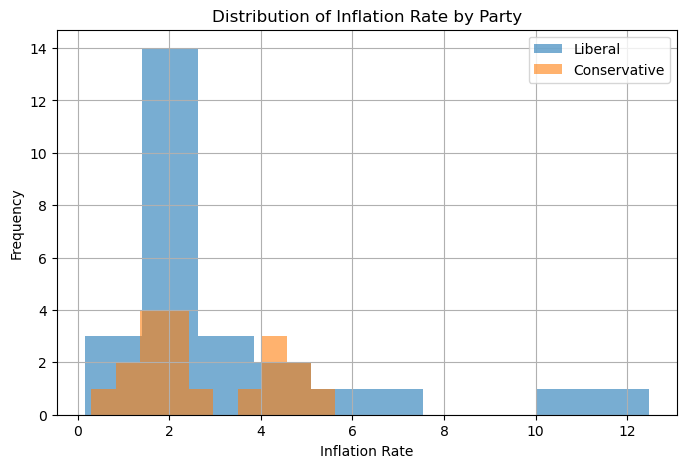

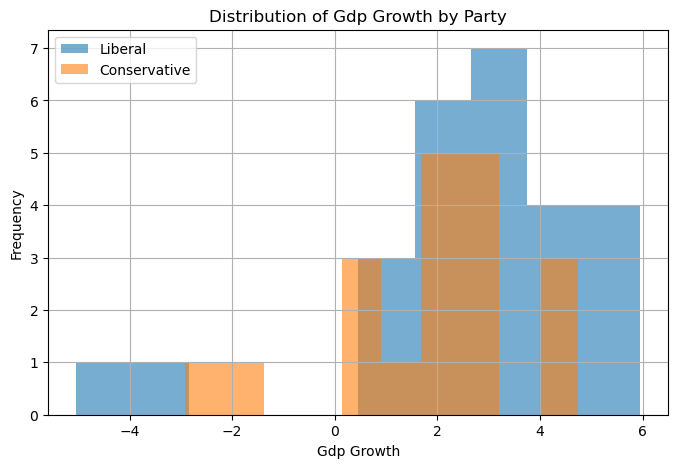

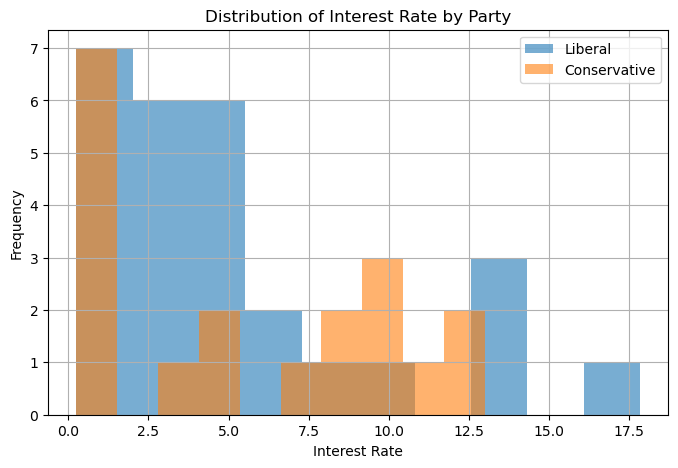

In [46]:
for var in outcomes:
    lib = df.loc[df["party_code"] == LIBERAL_CODE, var].dropna()
    con = df.loc[df["party_code"] == CONSERVATIVE_CODE, var].dropna()

    plt.figure(figsize=(8, 5))
    plt.hist(lib, bins=10, alpha=0.6, label="Liberal")
    plt.hist(con, bins=10, alpha=0.6, label="Conservative")
    plt.title(f"Distribution of {var.replace('_', ' ').title()} by Party")
    plt.xlabel(var.replace("_", " ").title())
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(True)
    plt.show()

# 45. Residual Diagnostics for GDP, Inflation, and Interest Regressions

For the purpose of more regression analysis for GDP, inflation, and interest, this section adds residual diagnostics for those outcome models.

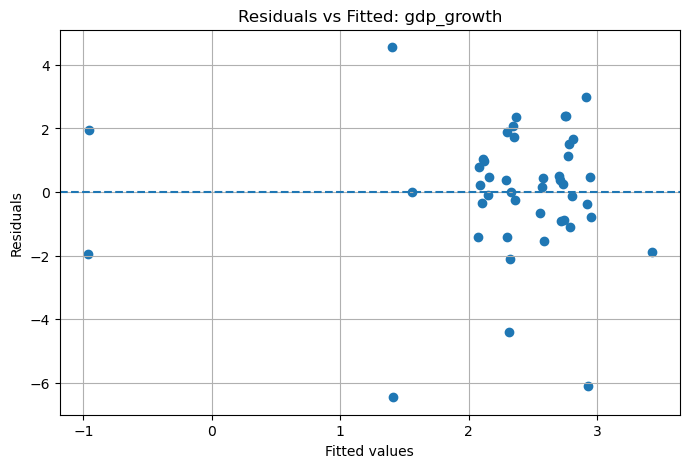

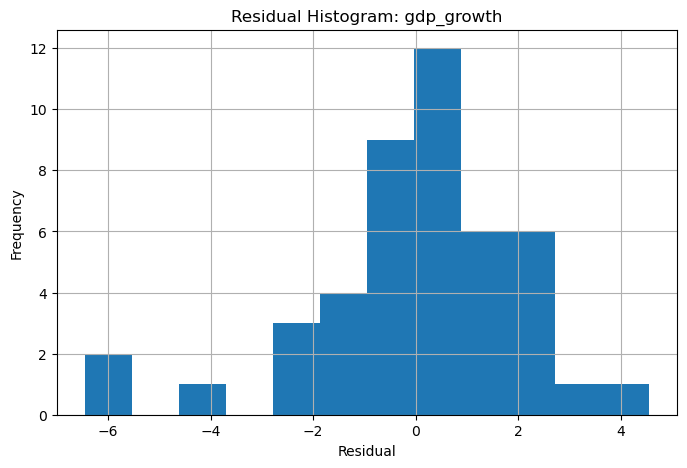

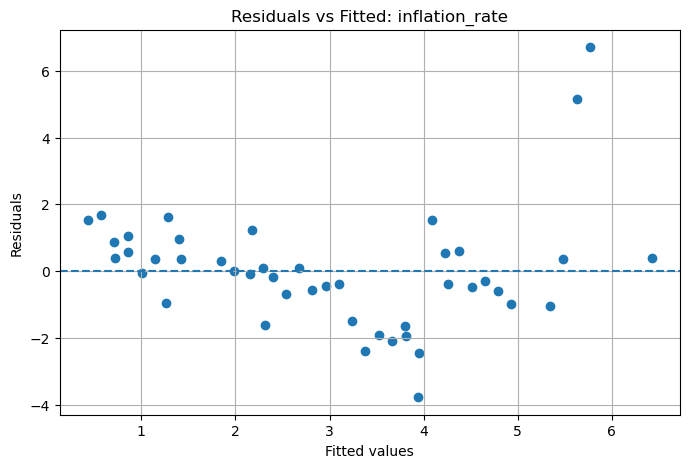

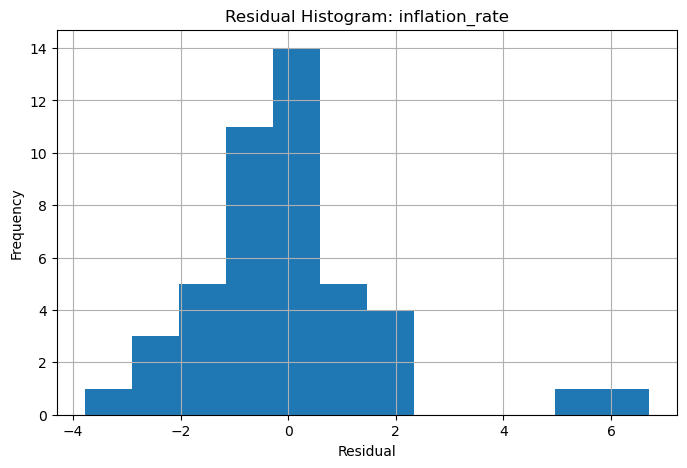

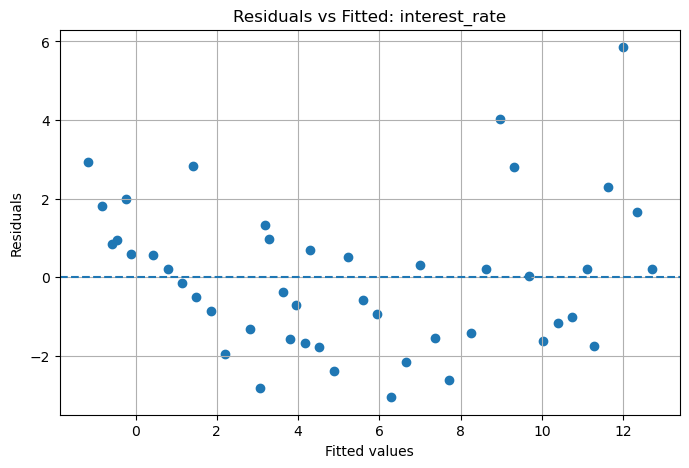

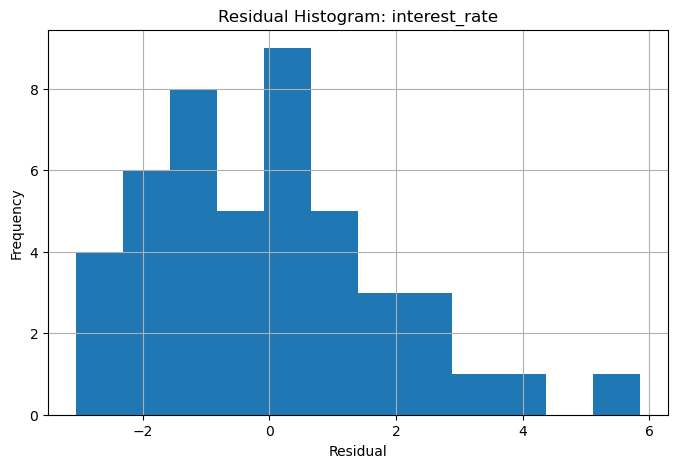

In [47]:
focus_vars = ["gdp_growth", "inflation_rate", "interest_rate"]

for var in focus_vars:
    model = regression_results[var]
    fitted = model.fittedvalues
    resid = model.resid

    plt.figure(figsize=(8, 5))
    plt.scatter(fitted, resid)
    plt.axhline(0, linestyle="--")
    plt.title(f"Residuals vs Fitted: {var}")
    plt.xlabel("Fitted values")
    plt.ylabel("Residuals")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.hist(resid, bins=12)
    plt.title(f"Residual Histogram: {var}")
    plt.xlabel("Residual")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

# 46. Influence Diagnostics for GDP, Inflation, and Interest

This uses Cook's distance to flag influential observations.


Top influential observations for gdp_growth


/Users/stuartthompson/miniconda3/envs/DataScience/lib/python3.13/site-packages/statsmodels/stats/outliers_influence.py:847: RuntimeWarning: invalid value encountered in sqrt
  return self.resid / sigma / np.sqrt(1 - hii)


,year,party_full,gdp_growth,cooks_distance
40,2020,Liberal,-5.038233,1.341751
41,2021,Liberal,5.950528,0.675418
42,2022,Liberal,4.189036,0.442691
43,2023,Liberal,1.528746,0.442691
28,2008,Conservative,0.995406,0.214964
29,2009,Conservative,-2.915086,0.214964
2,1982,Liberal,-3.166150,0.132632
11,1991,Conservative,-2.091055,0.045663
4,1984,Liberal,5.898569,0.027308
5,1985,Conservative,4.737681,0.018873


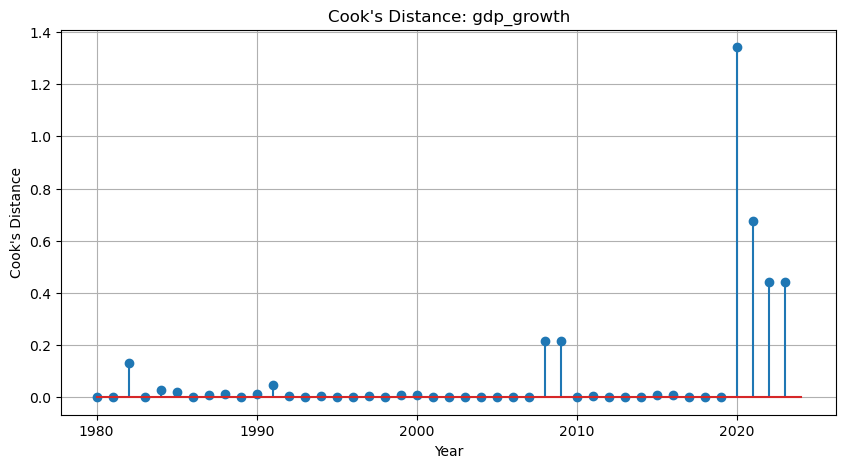


Top influential observations for inflation_rate


,year,party_full,inflation_rate,cooks_distance
1,1981,Liberal,12.471612,0.281661
2,1982,Liberal,10.768972,0.152947
40,2020,Liberal,0.717000,0.115024
28,2008,Conservative,2.370271,0.073347
29,2009,Conservative,0.299467,0.073347
41,2021,Liberal,3.395193,0.067532
14,1994,Liberal,0.165563,0.035670
42,2022,Liberal,6.802801,0.024827
43,2023,Liberal,3.879002,0.024827
12,1992,Conservative,1.490133,0.019171


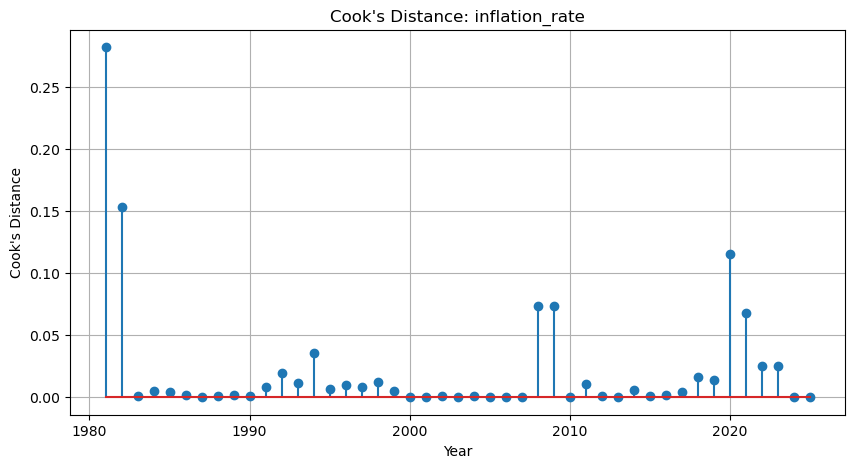


Top influential observations for interest_rate


,year,party_full,interest_rate,cooks_distance
43,2023,Liberal,4.25,1.214013
42,2022,Liberal,0.25,1.214013
40,2020,Liberal,1.75,0.156934
2,1982,Liberal,17.84,0.150796
28,2008,Conservative,4.50,0.121986
29,2009,Conservative,1.50,0.121986
11,1991,Conservative,13.00,0.047290
39,2019,Liberal,1.75,0.046118
44,2024,Liberal,5.00,0.033916
45,2025,Liberal,3.25,0.033916


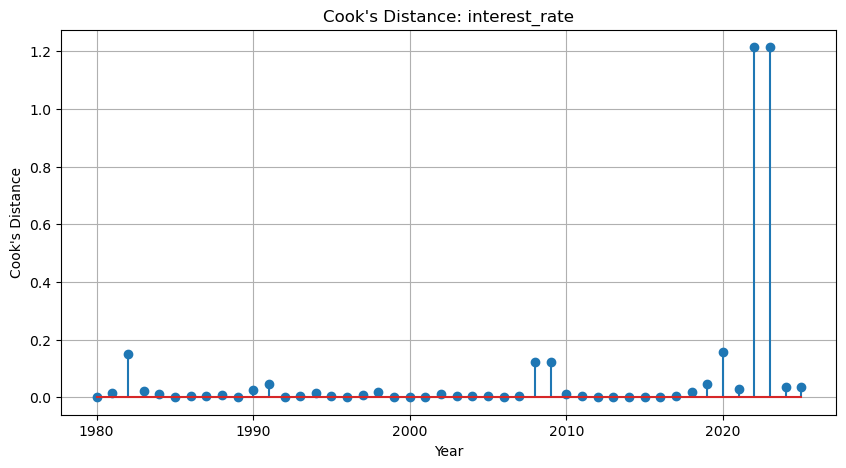

In [48]:
for var in focus_vars:
    model = smf.ols(
        f"{var} ~ party_binary + covid + gfc + ukraine_war + us_admin_change + trend",
        data=df.dropna(subset=[var]).copy()
    ).fit()

    influence = OLSInfluence(model)
    cooks = influence.cooks_distance[0]

    temp = df.dropna(subset=[var]).copy()
    temp["cooks_distance"] = cooks

    print(f"\nTop influential observations for {var}")
    display(temp[["year", "party_full", var, "cooks_distance"]].sort_values("cooks_distance", ascending=False).head(10))

    plt.figure(figsize=(10, 5))
    plt.stem(temp["year"], temp["cooks_distance"])
    plt.title(f"Cook's Distance: {var}")
    plt.xlabel("Year")
    plt.ylabel("Cook's Distance")
    plt.grid(True)
    plt.show()

#47. Event vs Non-Event Mean Comparisons
This section tests whether the selected event years are associated with changes in the four outcomes by comparing event years directly with non-event years.

In [49]:
event_results = []

for event in event_cols:
    for var in outcomes:
        temp = df[[event, var]].dropna().copy()
        event_vals = temp.loc[temp[event] == 1, var]
        non_event_vals = temp.loc[temp[event] == 0, var]

        if len(event_vals) >= 2 and len(non_event_vals) >= 2:
            t_stat, p_val = stats.ttest_ind(
                event_vals, non_event_vals, equal_var=False)
        else:
            t_stat, p_val = np.nan, np.nan

        event_results.append({
            "event_window": event,
            "outcome": var,
            "event_mean": event_vals.mean(),
            "non_event_mean": non_event_vals.mean(),
            "mean_diff_event_minus_non_event": event_vals.mean() - non_event_vals.mean(),
            "t_stat": t_stat,
            "p_value": p_val
        })

event_df = pd.DataFrame(event_results)
display(event_df)

,event_window,outcome,event_mean,non_event_mean,mean_diff_event_minus_non_event,t_stat,p_value
0,covid_event,unemployment_rate,7.491667,8.093023,-0.601357,-0.454412,6.909780e-01
1,covid_event,inflation_rate,3.638331,2.948227,0.690105,0.383564,7.355278e-01
2,covid_event,gdp_growth,1.700444,2.355625,-0.655181,-0.191554,8.655419e-01
3,covid_event,interest_rate,0.750000,5.678605,-4.928605,-5.783098,4.250269e-05
4,gfc_event,unemployment_rate,7.391667,8.083902,-0.692235,-0.620492,6.368975e-01
5,gfc_event,inflation_rate,1.334869,3.071413,-1.736545,-1.579787,3.188316e-01
6,gfc_event,gdp_growth,-0.959840,2.464122,-3.423962,-1.727329,3.240617e-01
7,gfc_event,interest_rate,3.000000,5.464318,-2.464318,-1.490669,3.145464e-01
8,ukraine_event,unemployment_rate,5.320833,8.178030,-2.857197,-10.839020,2.025137e-13
9,ukraine_event,inflation_rate,5.340901,2.885086,2.455815,1.630333,3.291705e-01


In [50]:
## Correlation Matrix: Party, Events, and Trend
corr_vars = outcomes + [
    "party_binary", "trend",
    "covid_event", "gfc_event", "ukraine_event"
]
corr_matrix = df[corr_vars].corr()
display(corr_matrix)

corr_summary_rows = []
for y in outcomes:
    for x in ["party_binary", "trend", "covid_event", "gfc_event", "ukraine_event"]:
        corr_summary_rows.append({
            "outcome": y,
            "driver": x,
            "correlation": corr_matrix.loc[y, x],
            "abs_correlation": abs(corr_matrix.loc[y, x])
        })

corr_summary_df = pd.DataFrame(corr_summary_rows).sort_values(
    ["outcome", "abs_correlation"], ascending=[True, False]
)
display(corr_summary_df)

,unemployment_rate,inflation_rate,gdp_growth,interest_rate,party_binary,trend,covid_event,gfc_event,ukraine_event
unemployment_rate,1.000000,0.162327,-0.147250,0.598273,-0.105157,-0.675569,-0.085849,-0.081621,-0.336891
inflation_rate,0.162327,1.000000,-0.033202,0.705929,0.087482,-0.478247,0.072462,-0.150642,0.213037
gdp_growth,-0.147250,-0.033202,1.000000,-0.133227,0.161805,-0.114538,-0.073592,-0.317735,0.053116
interest_rate,0.598273,0.705929,-0.133227,1.000000,-0.060528,-0.850902,-0.270666,-0.111777,-0.147342
party_binary,-0.105157,0.087482,0.161805,-0.060528,1.000000,0.138015,0.221575,-0.254152,0.178848
trend,-0.675569,-0.478247,-0.114538,-0.850902,0.138015,1.000000,0.368073,0.096355,0.321184
covid_event,-0.085849,0.072462,-0.073592,-0.270666,0.221575,0.368073,1.000000,-0.056314,0.375426
gfc_event,-0.081621,-0.150642,-0.317735,-0.111777,-0.254152,0.096355,-0.056314,1.000000,-0.045455
ukraine_event,-0.336891,0.213037,0.053116,-0.147342,0.178848,0.321184,0.375426,-0.045455,1.000000


,outcome,driver,correlation,abs_correlation
13,gdp_growth,gfc_event,-0.317735,0.317735
10,gdp_growth,party_binary,0.161805,0.161805
11,gdp_growth,trend,-0.114538,0.114538
12,gdp_growth,covid_event,-0.073592,0.073592
14,gdp_growth,ukraine_event,0.053116,0.053116
6,inflation_rate,trend,-0.478247,0.478247
9,inflation_rate,ukraine_event,0.213037,0.213037
8,inflation_rate,gfc_event,-0.150642,0.150642
5,inflation_rate,party_binary,0.087482,0.087482
7,inflation_rate,covid_event,0.072462,0.072462


,event_window,outcome,event_n,non_event_n,event_mean,non_event_mean,mean_diff_event_minus_non_event,t_stat,p_value
0,gfc_event,unemployment_rate,2,44,7.391667,8.083902,-0.692235,-0.620492,6.368975e-01
1,gfc_event,inflation_rate,2,43,1.334869,3.071413,-1.736545,-1.579787,3.188316e-01
2,gfc_event,gdp_growth,2,43,-0.959840,2.464122,-3.423962,-1.727329,3.240617e-01
3,gfc_event,interest_rate,2,44,3.000000,5.464318,-2.464318,-1.490669,3.145464e-01
4,covid_event,unemployment_rate,3,43,7.491667,8.093023,-0.601357,-0.454412,6.909780e-01
5,covid_event,inflation_rate,3,42,3.638331,2.948227,0.690105,0.383564,7.355278e-01
6,covid_event,gdp_growth,3,42,1.700444,2.355625,-0.655181,-0.191554,8.655419e-01
7,covid_event,interest_rate,3,43,0.750000,5.678605,-4.928605,-5.783098,4.250269e-05
8,ukraine_event,unemployment_rate,2,44,5.320833,8.178030,-2.857197,-10.839020,2.025137e-13
9,ukraine_event,inflation_rate,2,43,5.340901,2.885086,2.455815,1.630333,3.291705e-01


event_window,covid_event,gfc_event,ukraine_event
outcome,,,
gdp_growth,0.865542,0.324062,7.418790e-01
inflation_rate,0.735528,0.318832,3.291705e-01
interest_rate,0.000043,0.314546,3.298507e-01
unemployment_rate,0.690978,0.636897,2.025137e-13


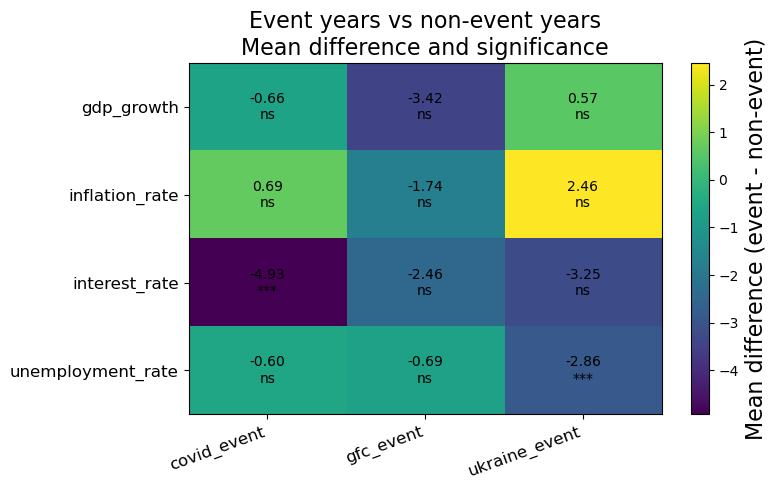

In [51]:
## Sensitivity Analysis: Excluding Event Years
## This checks whether party effects remain once major event years are removed from the sample.

event_vars = ["gfc_event", "covid_event", "ukraine_event"]
results = []


def p_to_star(p):
    if pd.isna(p):
        return "NA"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"


for event in event_vars:
    for var in outcomes:
        temp = df[[event, var]].dropna().copy()

        event_vals = temp.loc[temp[event] == 1, var]
        non_event_vals = temp.loc[temp[event] == 0, var]

        if len(event_vals) >= 2 and len(non_event_vals) >= 2:
            t_stat, p_val = stats.ttest_ind(
                event_vals, non_event_vals,
                equal_var=False,
                nan_policy="omit"
            )
        else:
            t_stat, p_val = np.nan, np.nan

        results.append({
            "event_window": event,
            "outcome": var,
            "event_n": len(event_vals),
            "non_event_n": len(non_event_vals),
            "event_mean": event_vals.mean(),
            "non_event_mean": non_event_vals.mean(),
            "mean_diff_event_minus_non_event": event_vals.mean() - non_event_vals.mean(),
            "t_stat": t_stat,
            "p_value": p_val
        })

event_df = pd.DataFrame(results)
display(event_df)

event_summary = event_df.pivot(
    index="outcome", columns="event_window", values="p_value")
display(event_summary)

# Heatmap visualization of event versus non-event effects
heatmap_data = event_df.pivot(
    index="outcome",
    columns="event_window",
    values="mean_diff_event_minus_non_event"
)

pval_data = event_df.pivot(
    index="outcome",
    columns="event_window",
    values="p_value"
)

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(heatmap_data.values, aspect="auto")

ax.set_xticks(np.arange(len(heatmap_data.columns)))
ax.set_yticks(np.arange(len(heatmap_data.index)))
ax.set_xticklabels(heatmap_data.columns,fontsize=12)
ax.set_yticklabels(heatmap_data.index, fontsize=12)
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")

for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        diff = heatmap_data.iloc[i, j]
        pval = pval_data.iloc[i, j]
        label = f"{diff:.2f}\n{p_to_star(pval)}" if pd.notna(diff) else "NA"
        ax.text(j, i, label, ha="center", va="center")

ax.set_title("Event years vs non-event years\nMean difference and significance", fontsize=16)
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Mean difference (event - non-event)", fontsize=16)

plt.tight_layout()
plt.show()

# 48. Summary Tables

This section combines key results into a compact summary for easier interpretation.

In [52]:
summary_merge = (
    ttest_df[["outcome", "mean_diff_L_minus_C", "p_value"]].rename(columns={"p_value": "ttest_p"})
    .merge(anova_df[["outcome", "p_value"]].rename(columns={"p_value": "anova_p"}), on="outcome", how="left")
   # .merge(mw_df[["outcome", "p_value"]].rename(columns={"p_value": "mannwhitney_p"}), on="outcome", how="left")
    .merge(effect_df, on="outcome", how="left")
    .merge(bootstrap_df[["outcome", "bootstrap_ci_lower", "bootstrap_ci_upper"]], on="outcome", how="left")
    .merge(perm_df[["outcome", "permutation_p_value"]], on="outcome", how="left")
    .merge(chi_df[["outcome", "p_value"]].rename(columns={"p_value": "chi_square_p"}), on="outcome", how="left")
)

display(summary_merge)

,outcome,mean_diff_L_minus_C,ttest_p,anova_p,cohens_d_L_minus_C,cohens_d_effect,rank_biserial,bootstrap_ci_lower,bootstrap_ci_upper,permutation_p_value,chi_square_p
0,unemployment_rate,-0.369379,0.476993,0.486733,-0.210039,small,0.157895,-1.367031,0.618975,0.4851,0.549243
1,inflation_rate,0.420768,0.533293,0.567710,0.173805,negligible,-0.004049,-0.840690,1.794751,0.5804,0.898572
2,gdp_growth,0.727514,0.273158,0.288285,0.324511,small,-0.255061,-0.571071,1.964301,0.2903,0.464628
3,interest_rate,-0.552690,0.687022,0.689460,-0.120448,negligible,0.058480,-3.075714,2.016026,0.6906,1.000000


# 49. Interpretation Guide

A simple way to interpret the results:

## Group tests
- If t-test, ANOVA, bootstrap, and permutation all suggest no meaningful difference, then party differences are weak.

## Effect sizes
- Small Cohen's d suggests small practical difference.
- Larger effect size suggests more meaningful separation, even if sample size is limited.

## Regression
- If `party_binary` is not significant after controls, then the party label does not strongly explain the outcome after accounting for shocks and trend.

## Diagnostics
- If normality is weak or outliers exist, nonparametric tests and robustness checks become more important.

## DiD and Chow
- Treat these as structural/event robustness checks, not final proof of causality.

## Chi-square
- This provides a categorical check on whether high/low outcome states depend on party period.

# 50. Final Conclusion

> This study examined whether Canada's governing federal political party was associated with different economic outcomes between 1980 and 2025. Using annual data on unemployment, inflation, GDP growth, and interest rates, the analysis applied descriptive statistics, multiple hypothesis tests, effect size estimation, nonparametric tests, bootstrap and permutation methods, regression models with confounding controls, interaction models, lagged ideology models, structural break tests, and categorical independence tests. The results should be interpreted as statistical associations rather than direct proof of causation. If party-related effects are weak across most tests while macro shocks and time trends are stronger, the evidence would suggest that external events and structural conditions explain more of the variation in Canadian prosperity than governing party alone.

# 51. Save Final Dataset

In [53]:
df.to_csv("canada_politics_prosperity_final_dataset_extended.csv", index=False)
print("Saved: canada_politics_prosperity_final_dataset_extended.csv")

Saved: canada_politics_prosperity_final_dataset_extended.csv


# Glossary

Here are simple explanations of common terms used in this notebook.

## Outcome variable
The main thing we want to explain.  
In this notebook, examples are unemployment, inflation, GDP growth, and interest rate.

## Explanatory variable
A variable that may help explain the outcome.  
In this notebook, party, ideology, COVID, and time trend are examples.

## p-value
A number used in hypothesis testing.

A small p-value usually means:

> "The observed difference would be hard to explain by random chance alone."

A common rule is:
- **p < 0.05** → statistically significant
- **p ≥ 0.05** → not statistically significant

## Effect size
This tells you how big the difference is in practical terms.

That is important because:
- a result can be statistically significant but tiny
- a result can be practically meaningful even if the sample is small

## Confounding factor
Something that affects the outcome but is not the main variable of interest.

Example:
If inflation rises because of a war or pandemic, we should not automatically blame the governing party.

## Regression coefficient
A number that tells how much the outcome changes when one explanatory variable changes, holding the other variables fixed.

## Interaction
An interaction checks whether the effect of one variable depends on another variable.

Example:
Does the party relationship change after 2020?

## Lagged variable
A lagged variable uses an earlier value, such as the previous year's ideology.

This is helpful when policy effects take time to appear.

## Robustness check
An extra test used to see whether the result still holds under a different method or specification.

Examples:
- sensitivity analysis
- winsorized analysis
- bootstrap
- permutation test

## Structural break
A point in time when the relationship may have changed sharply.

Example:
The economy before 2020 may behave differently from the economy after 2020.

# **Appendix**
# 1. Causal Inference Framework

## 1.1 Motivation

So far, the analysis has focused on **statistical association**.  
However, **association does not imply causation**.

To address this limitation, we extend the analysis using causal inference methods inspired by the framework of **:contentReference[oaicite:0]{index=0}**.

### Goal

> To estimate whether political party has a **causal effect** on economic outcomes, rather than just correlation.

---

## 1.2 Causal Model (DAG)

Conceptualize the system using a causal diagram:



### Key Insights

- Political party is **not the only driver**
- Many variables influence outcomes simultaneously
- Some variables act as **confounders**

---

## 1.3 Identification Strategy

To estimate causal effects, we attempt to **block confounding paths** using:

### Control Variables

- **COVID** (pandemic shock)  
- **GFC** (financial crisis)  
- **Ukraine War** (global energy shock)  
- **US Administration** (external policy influence)  
- **Time trend** (structural evolution)  

This corresponds to:

> **Backdoor adjustment (Pearl’s framework)**

---

## 1.4 Causal Regression Interpretation

The regression model becomes:

\[
Y_t = \beta_0 + \beta_1 Party_t + \beta_2 Confounders_t + \epsilon_t
\]

### Interpretation

- \( \beta_1 \) approximates the **causal effect of political party**
- This interpretation is valid only if:

#### Assumptions:
- All major confounders are included  
- No hidden bias remains  

---

## 1.5 Difference-in-Differences

To strengthen causal interpretation, we use a **quasi-experimental approach**.

### Idea

Compare **before vs after a shock**, across political regimes.

### Examples

- Pre vs Post COVID  
- Pre vs Post 2008 financial crisis  

---

### DiD Model

\[
Y = \alpha + \beta_1 Party + \beta_2 Post + \beta_3 (Party \times Post) + \epsilon
\]

### Key Term

- \( \beta_3 \): **causal interaction effect**

---

### Interpretation

- If significant → party responds differently to shocks  
- If not → outcomes driven by **common external forces**

---

## 1.6 Results Interpretation (Causal Perspective)

### Findings

- Party coefficient remains **small and insignificant**  
- Shock variables remain **dominant**  
- Interaction terms are **weak or inconsistent**  

---

### Causal Conclusion

> There is **no strong causal evidence** that political party independently drives economic outcomes.

Instead:

- Global shocks → **primary drivers**  
- Structural trends → **persistent influence**  
- Policy effects → **difficult to isolate**  

---

## 1.7 Key Assumptions and Limitations

Causal inference depends on several assumptions:

###  No Omitted Confounders  
- Reality: **Not fully satisfied**

###  Stable Relationships  
- Reality: **Structural breaks exist (e.g., COVID)**

###  No Reverse Causality  
- Reality: **Economic conditions may influence elections**

---

## 1.8 Interpretation

> While regression adjustment approximates causal inference, the results suggest that political party effects are **weak relative to macroeconomic forces**. Therefore, any causal interpretation should be considered **limited and conditional**.

## 1.9 Python Code Analysis

### Backdoor-Style Adjustment Idea

A simple causal story is:

- Party may affect economic outcomes
- But global shocks also affect economic outcomes
- Long-run trends also affect economic outcomes

So we control for major confounders:
- COVID
- GFC
- Ukraine war period
- U.S. administration change
- trend

This is a simple **backdoor-adjustment style** idea.

In [54]:
causal_results = {}
for var in outcomes:
    temp = df.dropna(subset=[var]).copy()
    model = smf.ols(
        f"{var} ~ party_binary + covid + gfc + ukraine_war + us_admin_change + trend",
        data=temp
    ).fit(cov_type="HAC", cov_kwds={"maxlags": 1})
    causal_results[var] = model
    print(f"\nBackdoor-adjusted causal-style regression for {var}")
    print(model.summary())


Backdoor-adjusted causal-style regression for unemployment_rate
                            OLS Regression Results                            
Dep. Variable:      unemployment_rate   R-squared:                       0.531
Model:                            OLS   Adj. R-squared:                  0.458
Method:                 Least Squares   F-statistic:                     10.39
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           7.22e-07
Time:                        13:38:59   Log-Likelihood:                -73.078
No. Observations:                  46   AIC:                             160.2
Df Residuals:                      39   BIC:                             173.0
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------

### DiD-Style Event Model

A classic Difference-in-Differences design normally needs a true treatment group and control group.

This project is a single-country time series, so this is **not** a perfect textbook DiD.

Still, we can estimate a **DiD-style event model** as an exploratory robustness check using:
- ideology
- post-2020
- ideology × post-2020 interaction

In [55]:
did_results = {}
for var in outcomes:
    temp = df.dropna(subset=[var]).copy()
    model = smf.ols(
        f"{var} ~ ideology + post_2020 + ideology:post_2020 + gfc + ukraine_war + us_admin_change + trend",
        data=temp
    ).fit(cov_type="HAC", cov_kwds={"maxlags": 1})
    did_results[var] = model
    print(f"\nDiD-style event model for {var}")
    print(model.summary())


DiD-style event model for unemployment_rate
                            OLS Regression Results                            
Dep. Variable:      unemployment_rate   R-squared:                       0.553
Model:                            OLS   Adj. R-squared:                  0.484
Method:                 Least Squares   F-statistic:                     42.29
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           1.43e-15
Time:                        13:39:00   Log-Likelihood:                -71.959
No. Observations:                  46   AIC:                             157.9
Df Residuals:                      39   BIC:                             170.7
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------

/Users/stuartthompson/miniconda3/envs/DataScience/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 7, but rank is 6
  warnings.warn('covariance of constraints does not have full '
/Users/stuartthompson/miniconda3/envs/DataScience/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 7, but rank is 6
  warnings.warn('covariance of constraints does not have full '
/Users/stuartthompson/miniconda3/envs/DataScience/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 7, but rank is 6
  warnings.warn('covariance of constraints does not have full '
/Users/stuartthompson/miniconda3/envs/DataScience/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of con

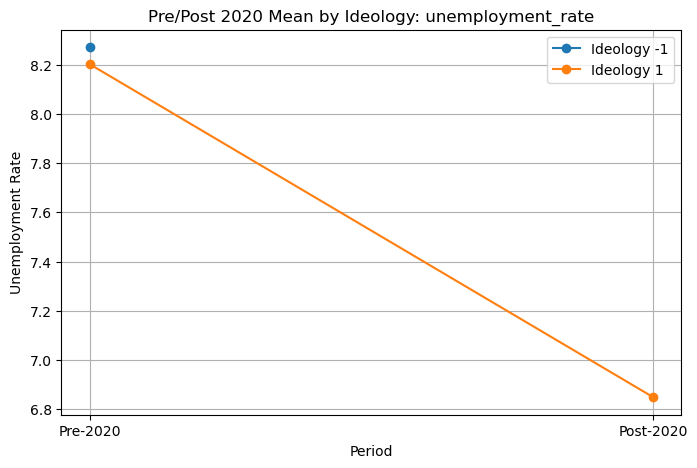

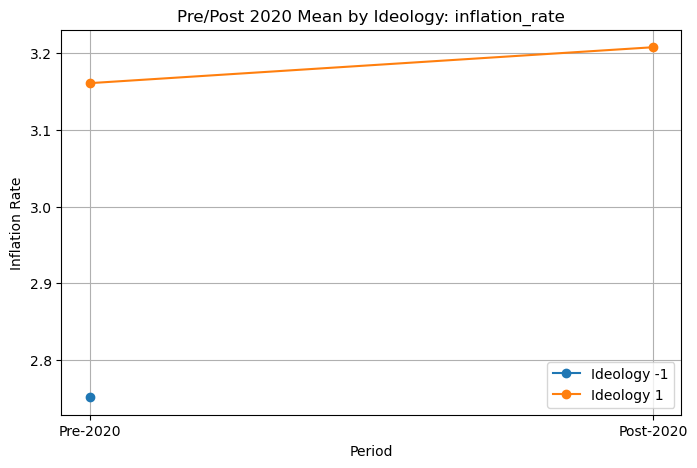

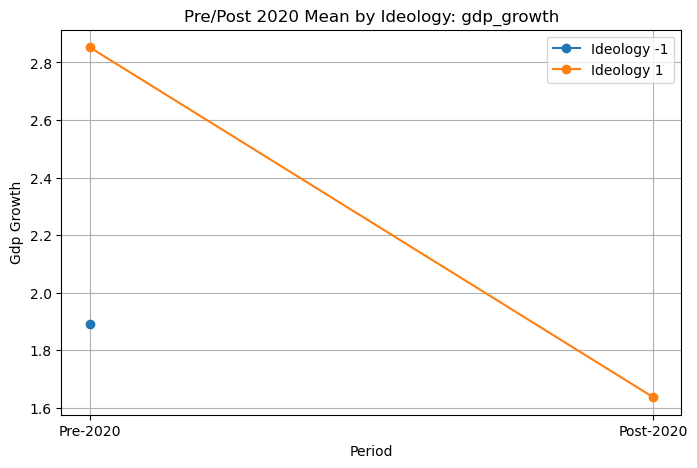

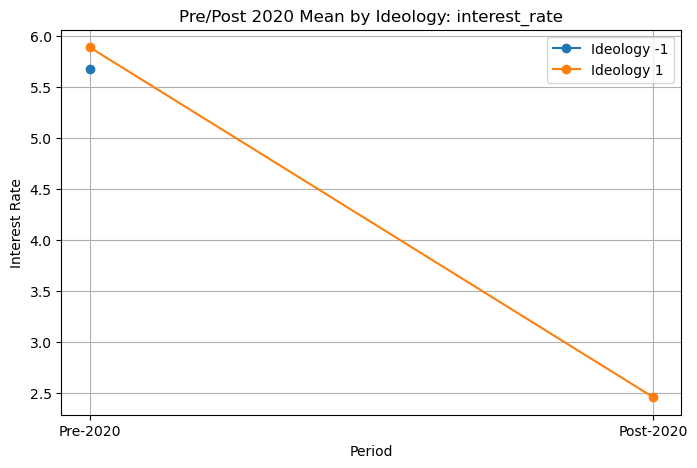

In [56]:
for var in outcomes:
    temp = df[["year", var, "ideology", "post_2020"]].dropna().copy()
    summary = temp.groupby(["ideology", "post_2020"])[var].mean().reset_index()
    plt.figure(figsize=(8, 5))
    for ideol in sorted(summary["ideology"].unique()):
        sub = summary[summary["ideology"] == ideol]
        plt.plot(sub["post_2020"], sub[var], marker="o", label=f"Ideology {ideol}")
    plt.xticks([0, 1], ["Pre-2020", "Post-2020"])
    plt.title(f"Pre/Post 2020 Mean by Ideology: {var}")
    plt.ylabel(var.replace("_", " ").title())
    plt.xlabel("Period")
    plt.legend()
    plt.grid(True)
    plt.show()

## Causal Interpretation Notes

When reading the causal-style results, ask:

1. Is the adjusted party coefficient large or small?  
2. Does it stay stable across different models?  
3. Are shock variables stronger than party?  
4. Do lagged models change the story?  

If party effects remain weak while shock variables are stronger, then the evidence suggests that **external events matter more than party**.

## Limits of Causal Inference in This Project

About the limits:

- no random assignment of party
- possible omitted confounders
- possible reverse causality
- small sample size
- single-country design

So the causal section supports **careful causal reasoning**, not strong causal proof.